In [1]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
import pandas as pd
from joblib import Parallel, delayed
import numpy as np

In [2]:
gray_green = LinearSegmentedColormap.from_list(
    "gray_green", ["#D3D3D3", "#02500e", "#001203"]
)
gray_orange = LinearSegmentedColormap.from_list(
    "gray_orange", ["#D3D3D3", "#f76d48", "#FA4616"]
)

In [3]:
adata_transformed = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m3454_adata_subset_again_(50,34)_(0.1,1.2)_8_3_25.h5ad")

In [4]:
# set once in the main process
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*na_action.*Categorical\.map.*",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"No data for colormapping provided via 'c'.*cmap.*",)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [5]:
keep = [0,1,2,3,5,6]
adata_subset = adata_transformed[adata_transformed.obs["leiden"].isin(map(str, keep))].copy()

In [6]:
adata_subset

AnnData object with n_obs × n_vars = 1578 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [7]:
#save point
adata_subset_test=adata_subset.copy()


▶ Batch 1/57 | Combos 1–4


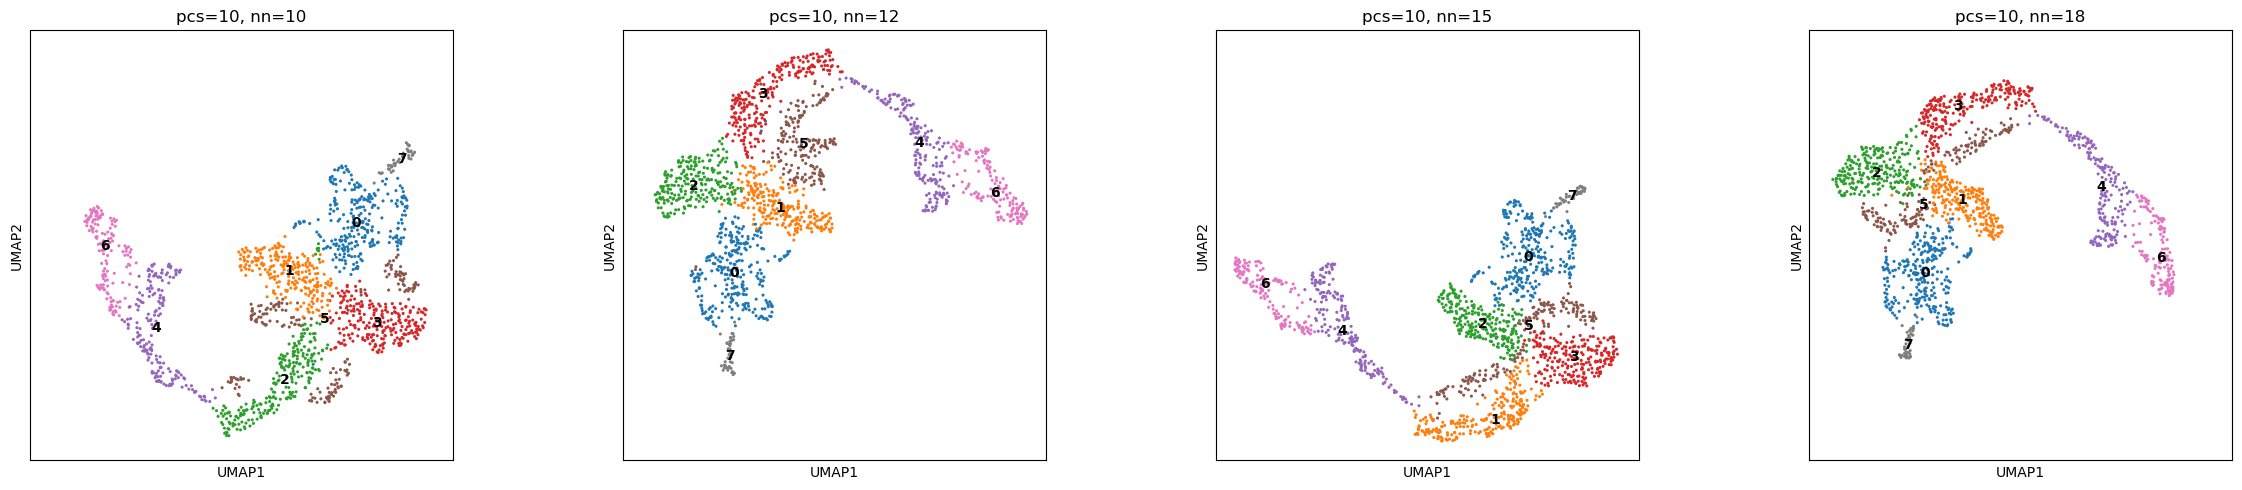


▶ Batch 2/57 | Combos 5–8


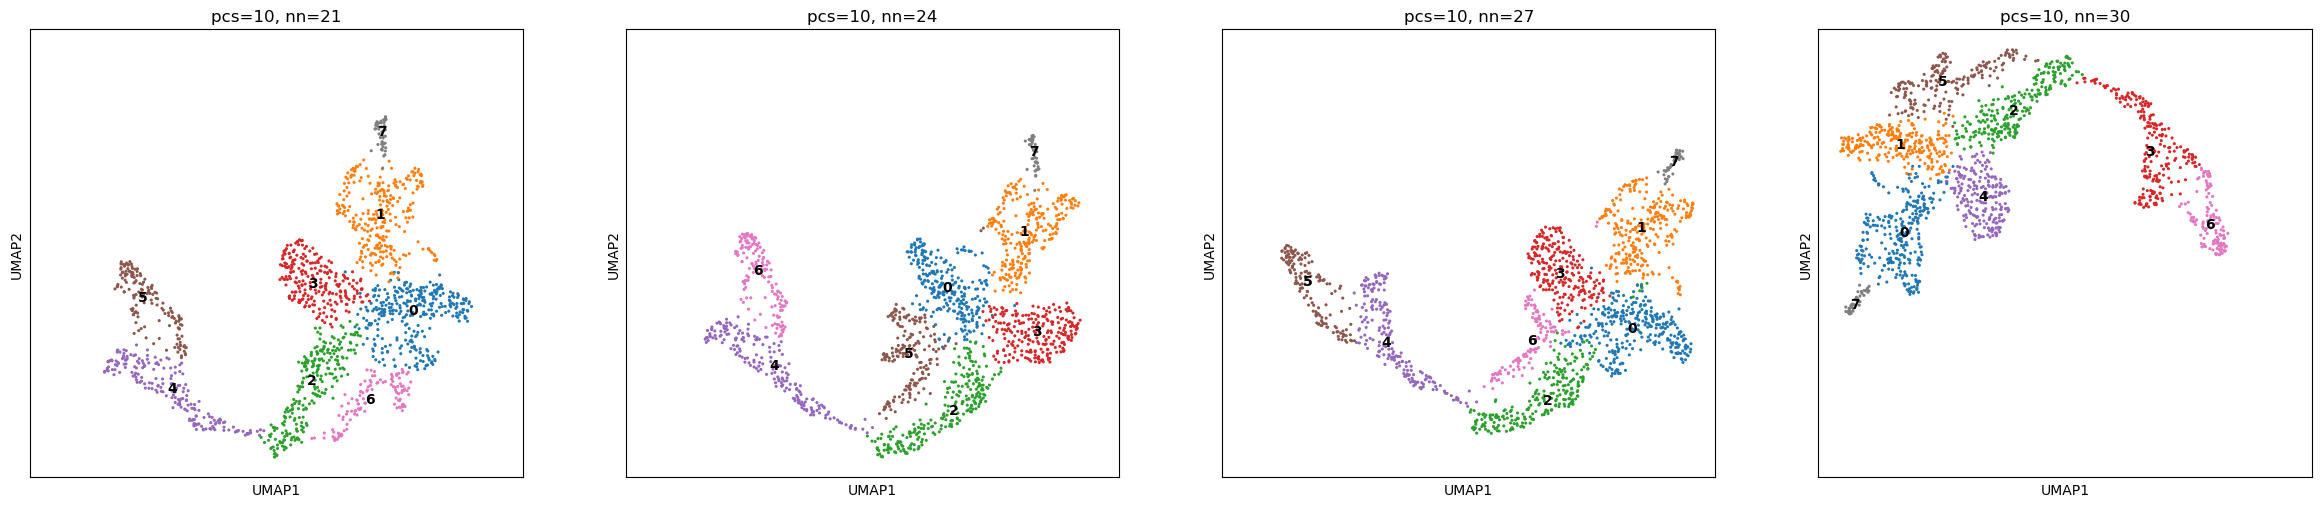


▶ Batch 3/57 | Combos 9–12


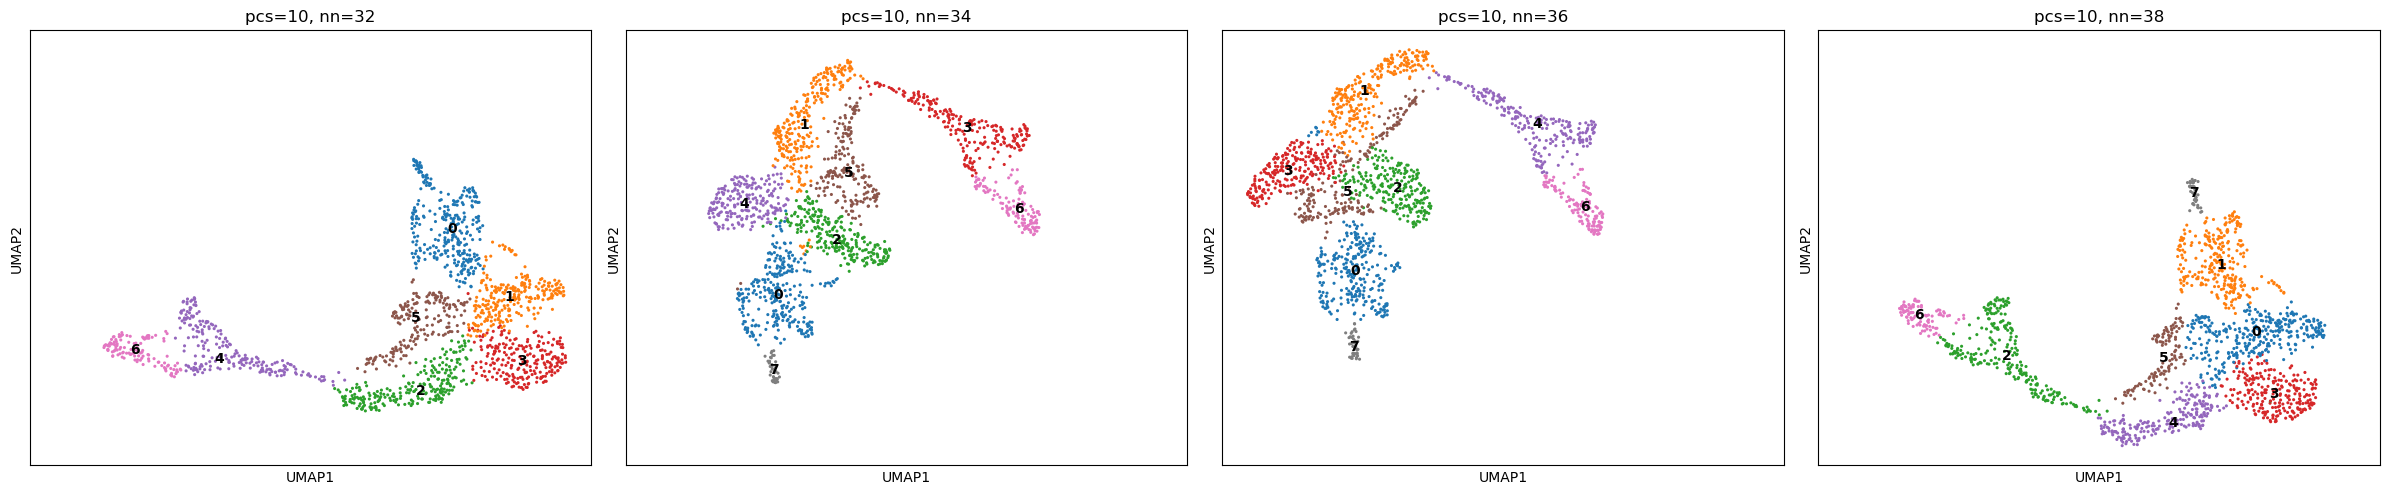


▶ Batch 4/57 | Combos 13–16


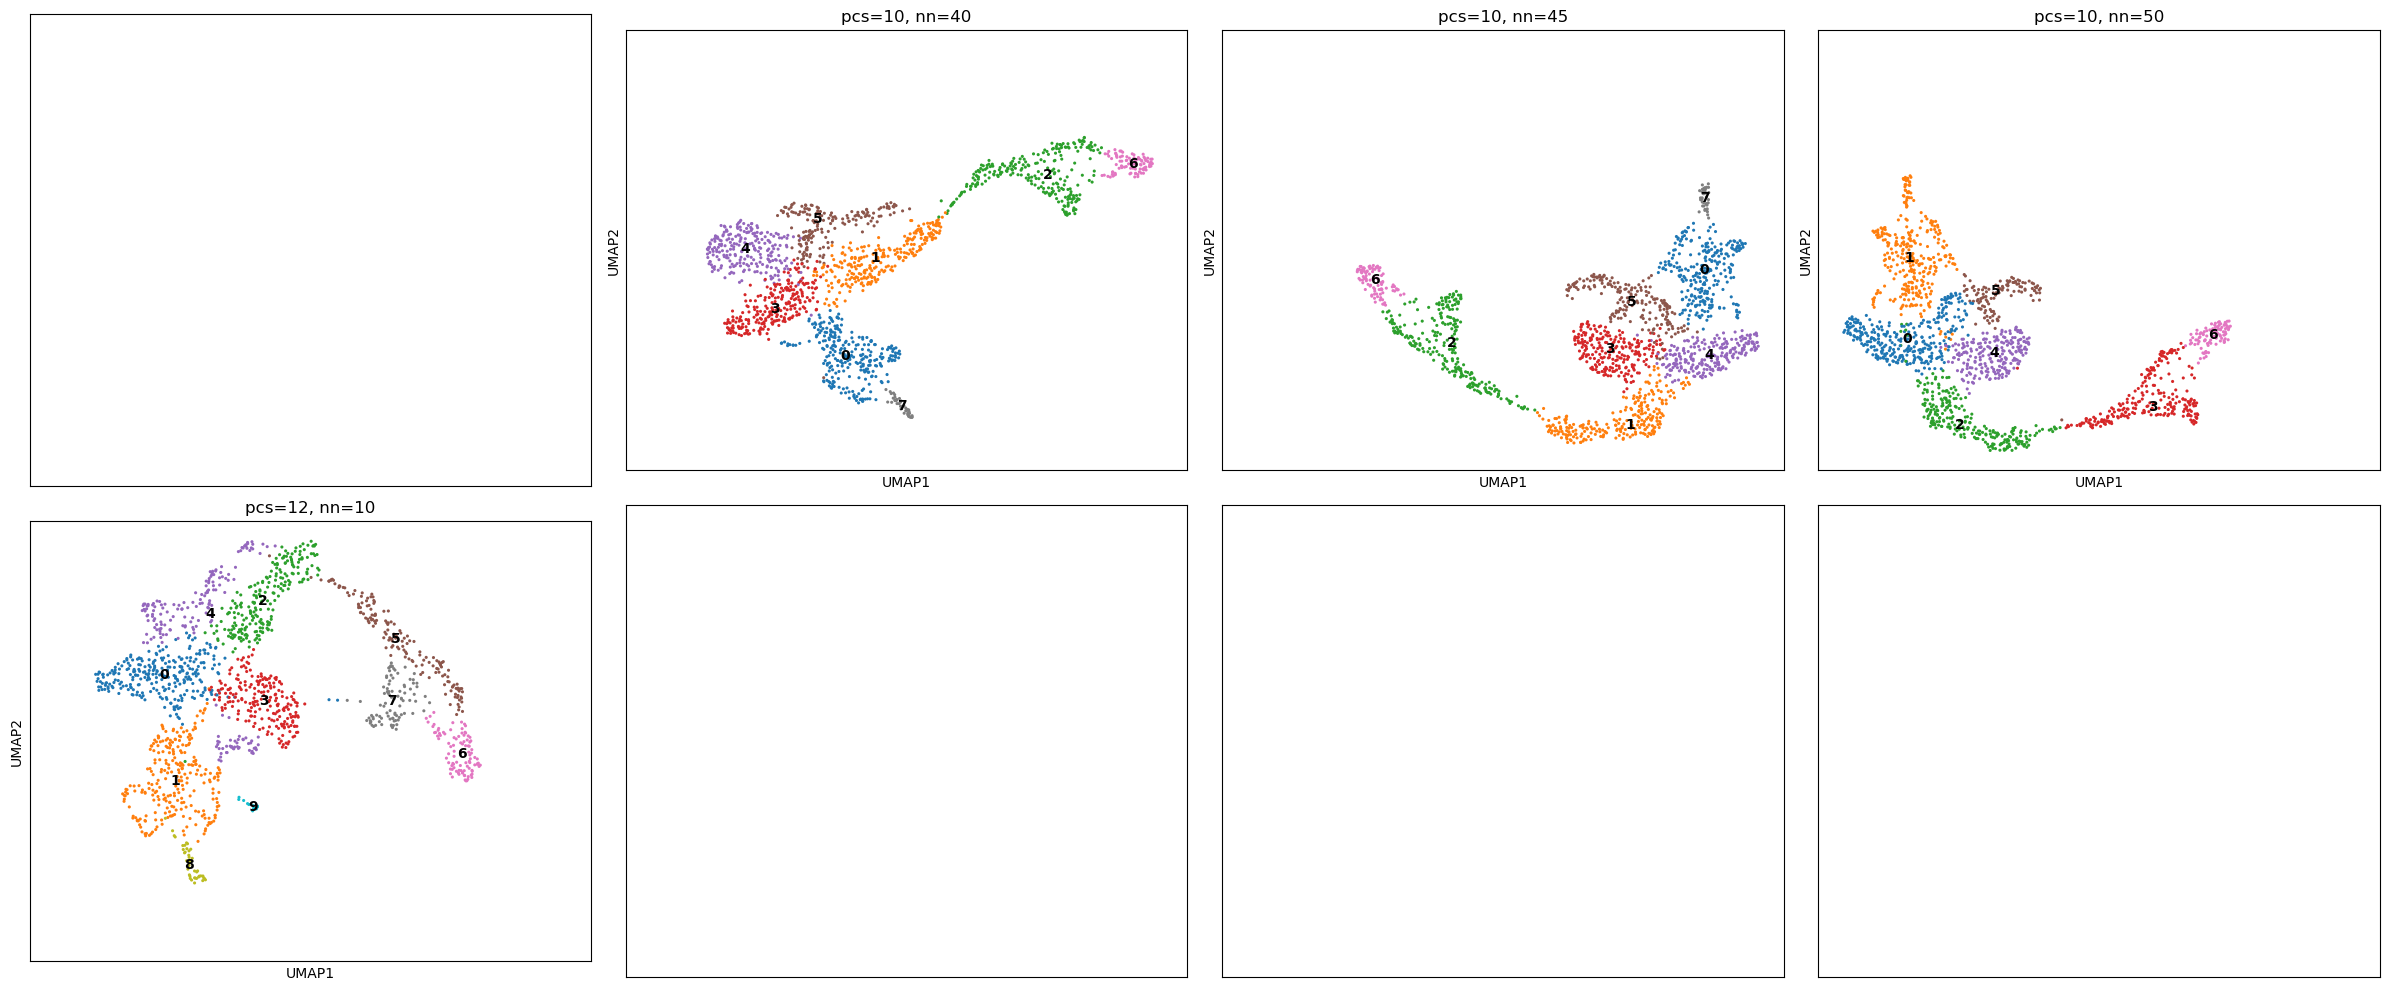


▶ Batch 5/57 | Combos 17–20


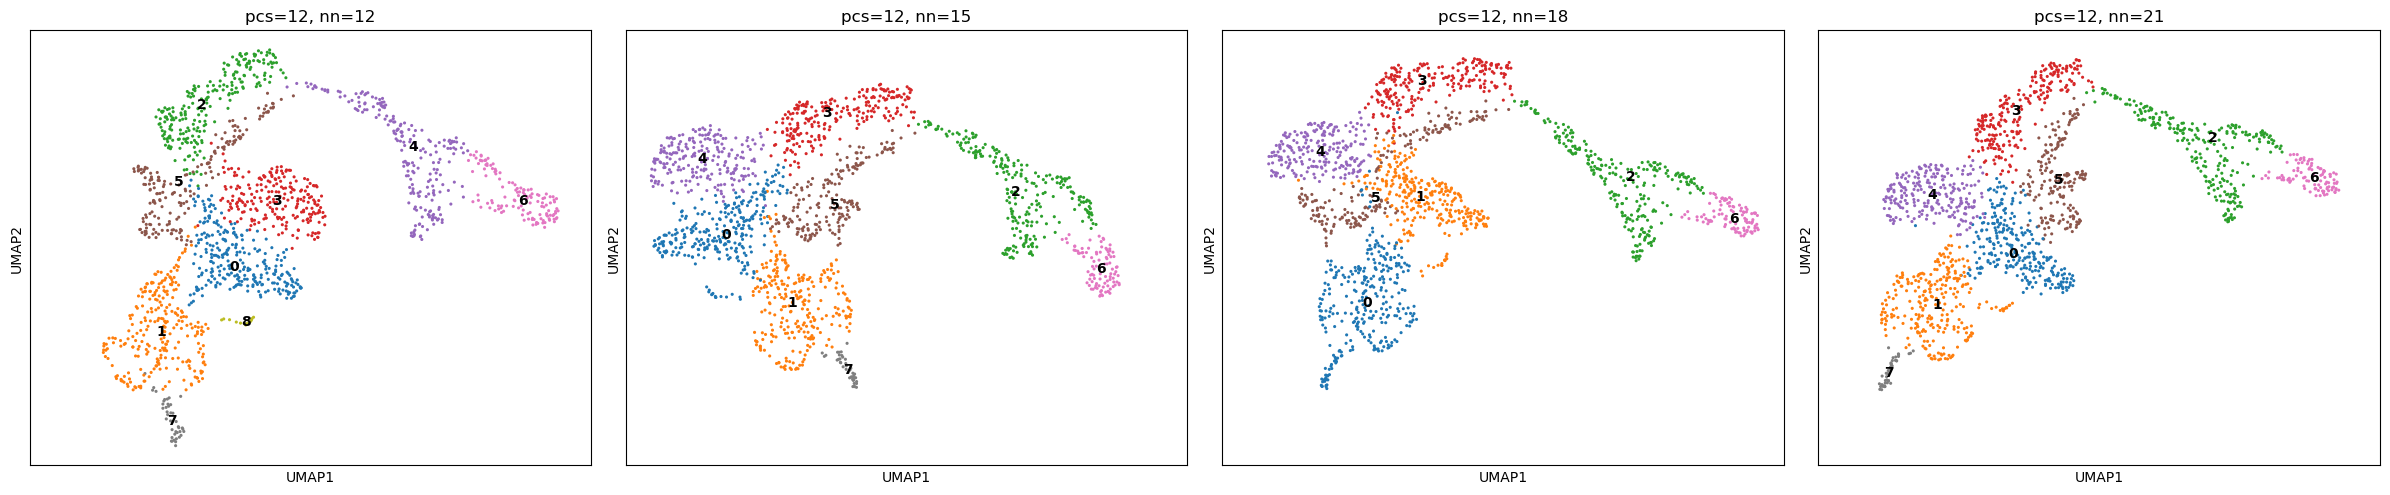


▶ Batch 6/57 | Combos 21–24


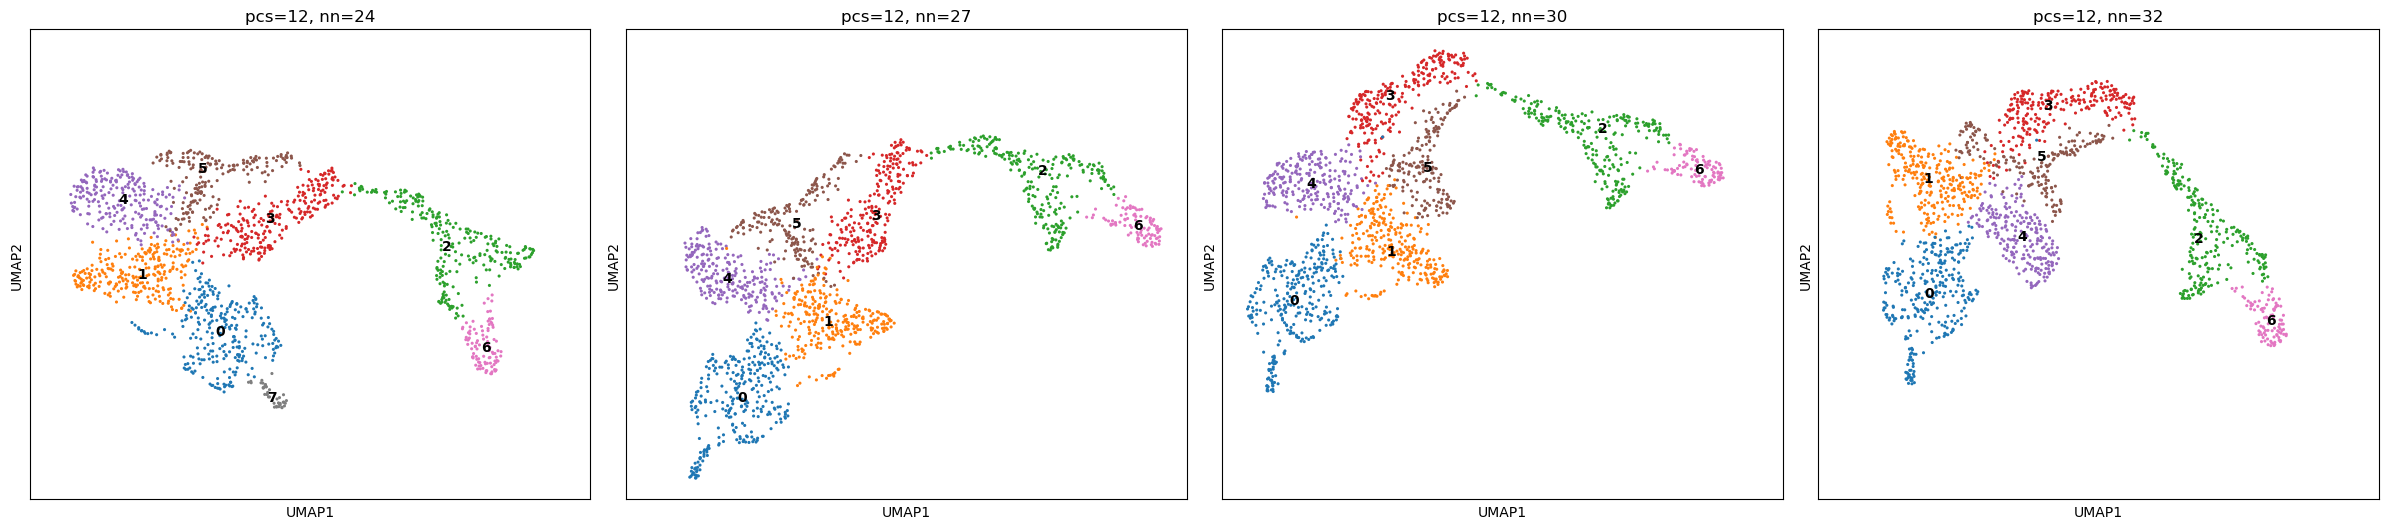


▶ Batch 7/57 | Combos 25–28


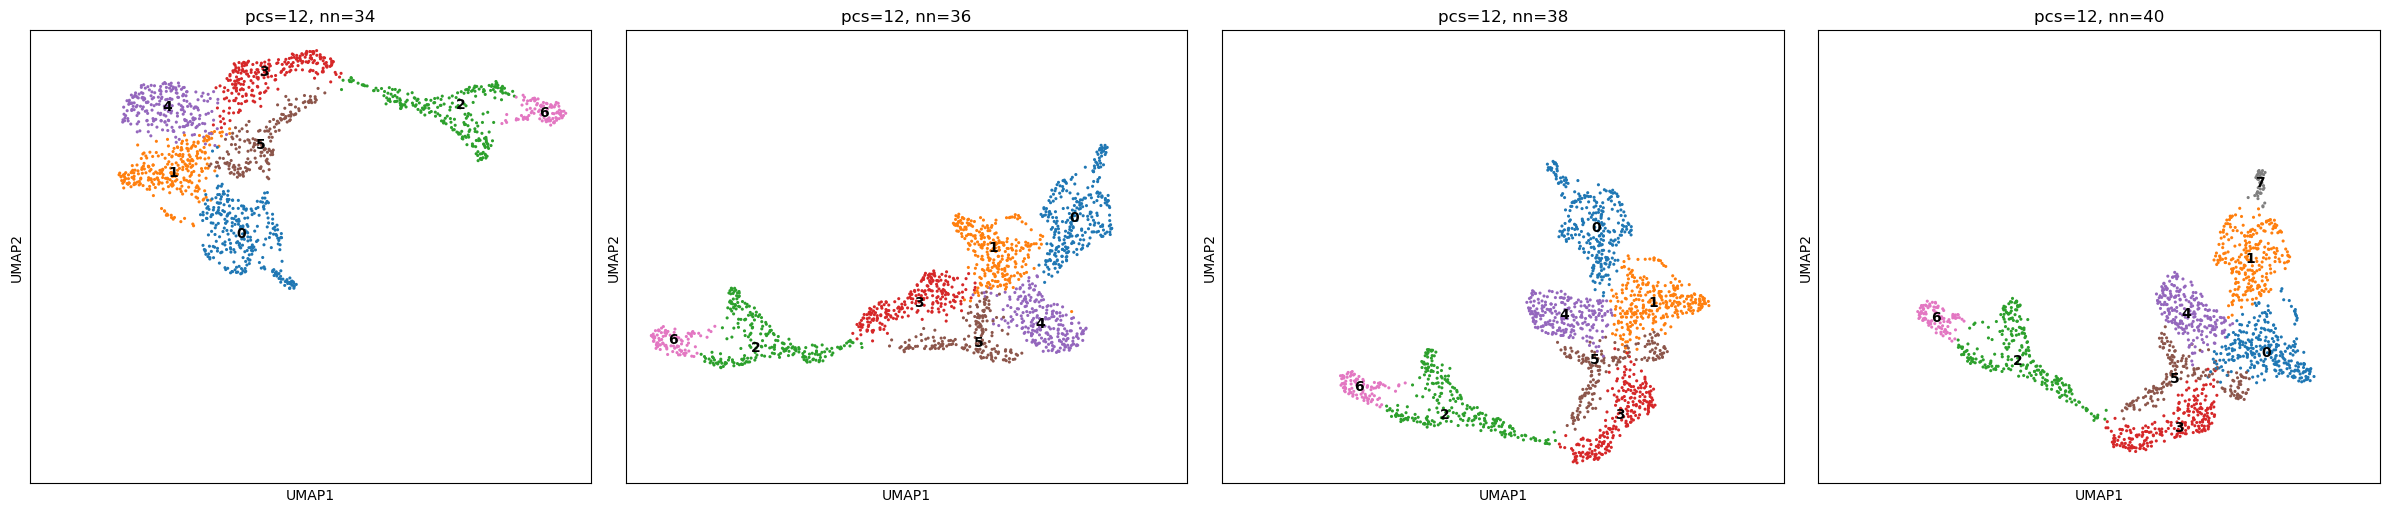


▶ Batch 8/57 | Combos 29–32


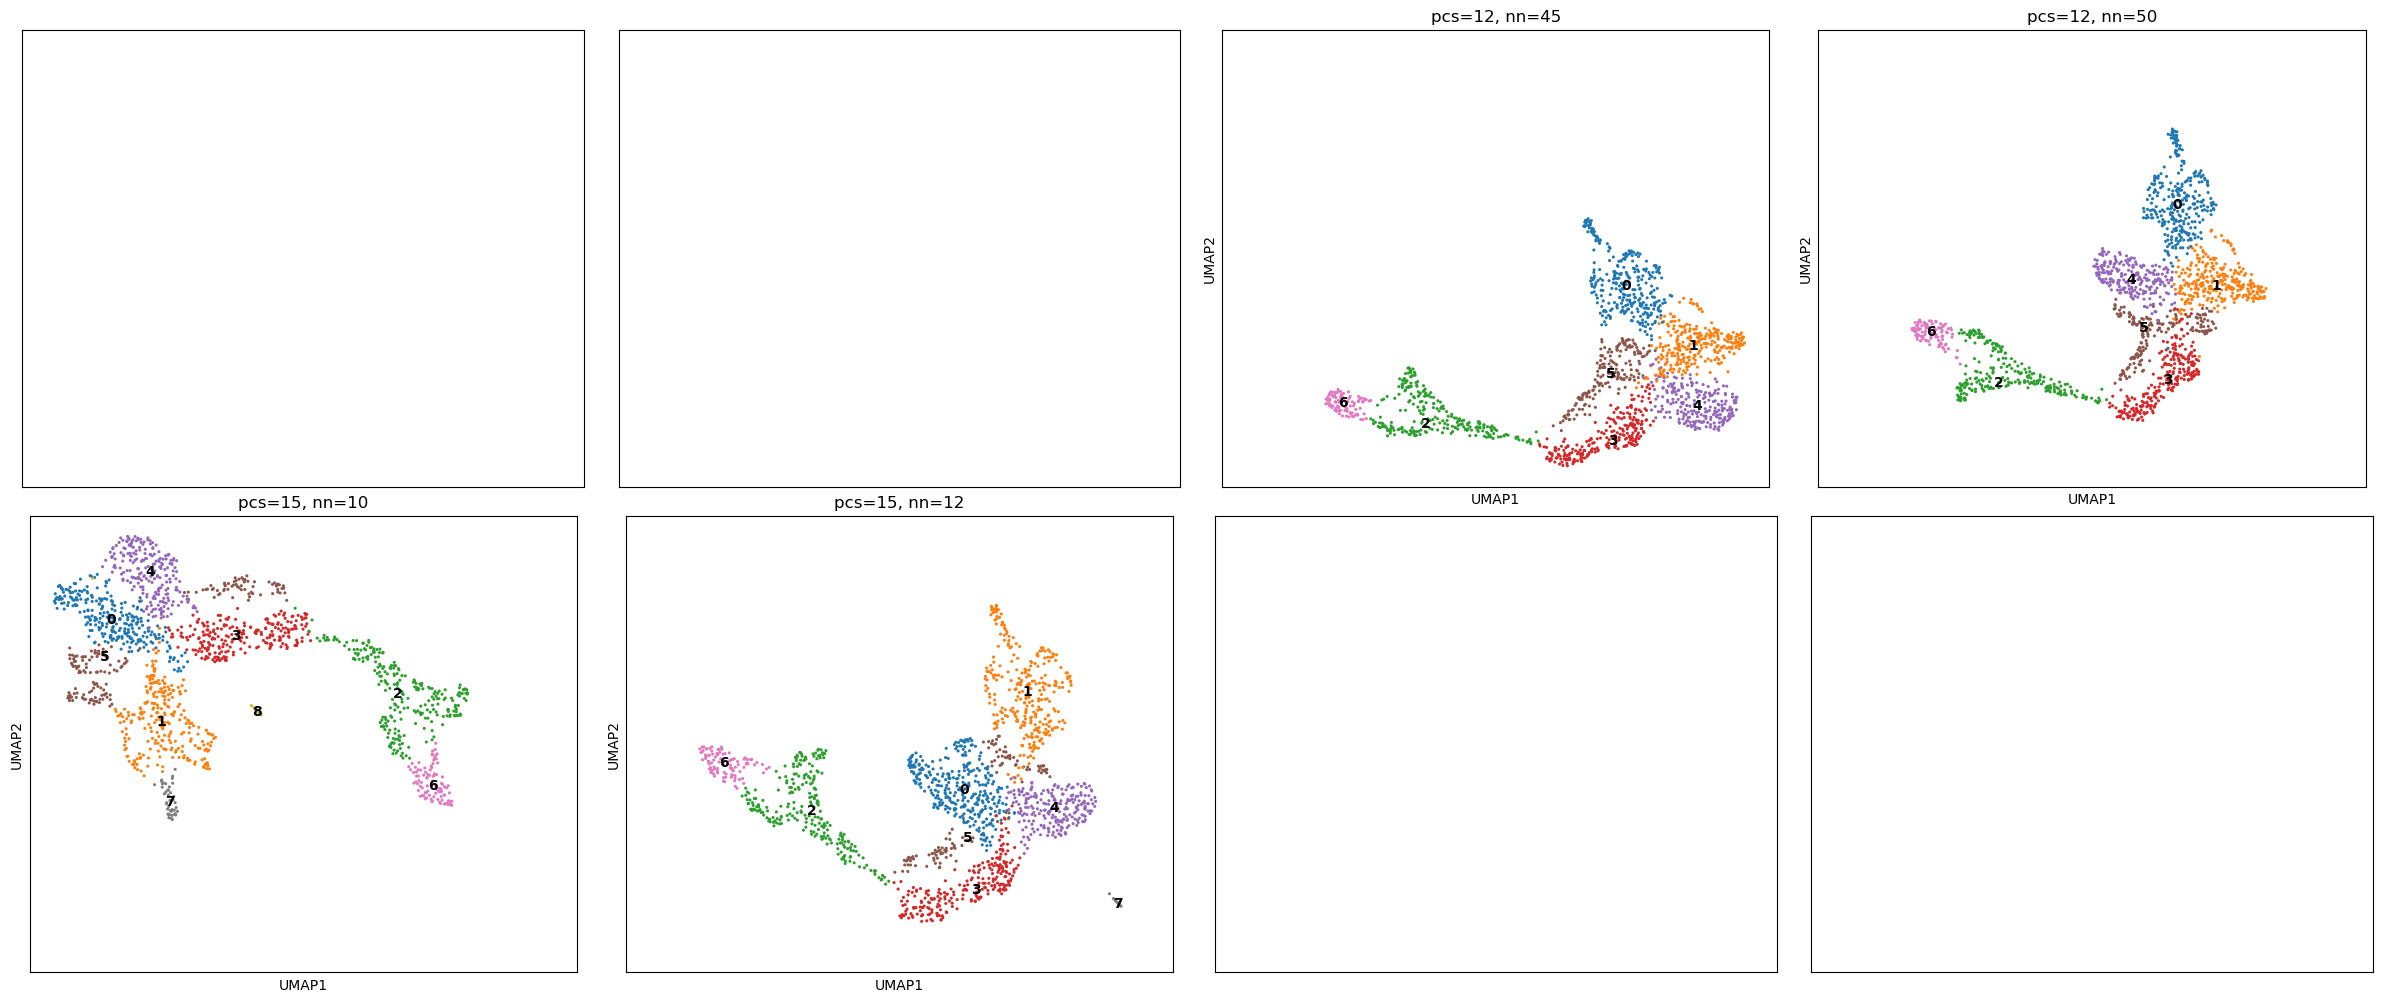


▶ Batch 9/57 | Combos 33–36


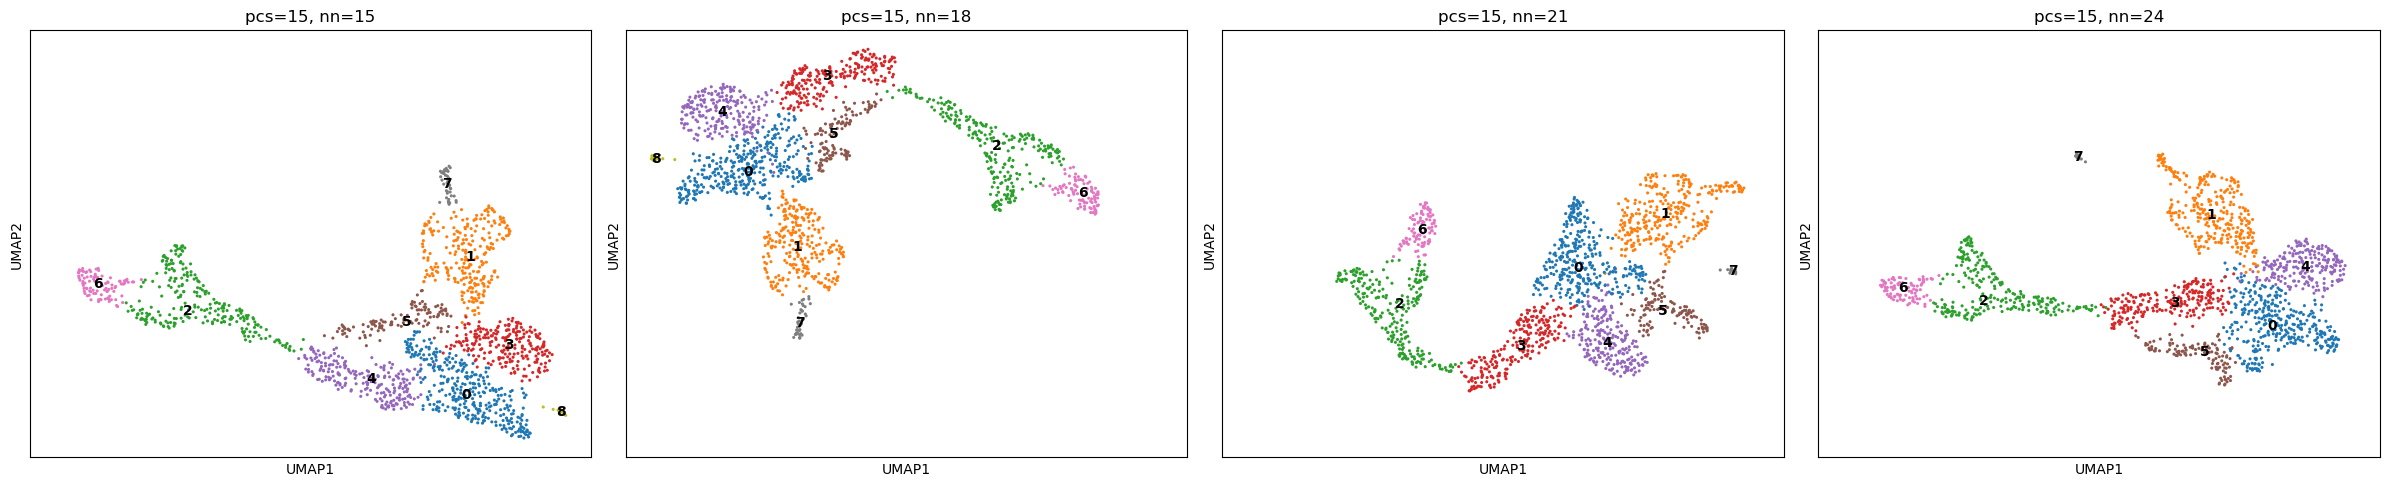


▶ Batch 10/57 | Combos 37–40


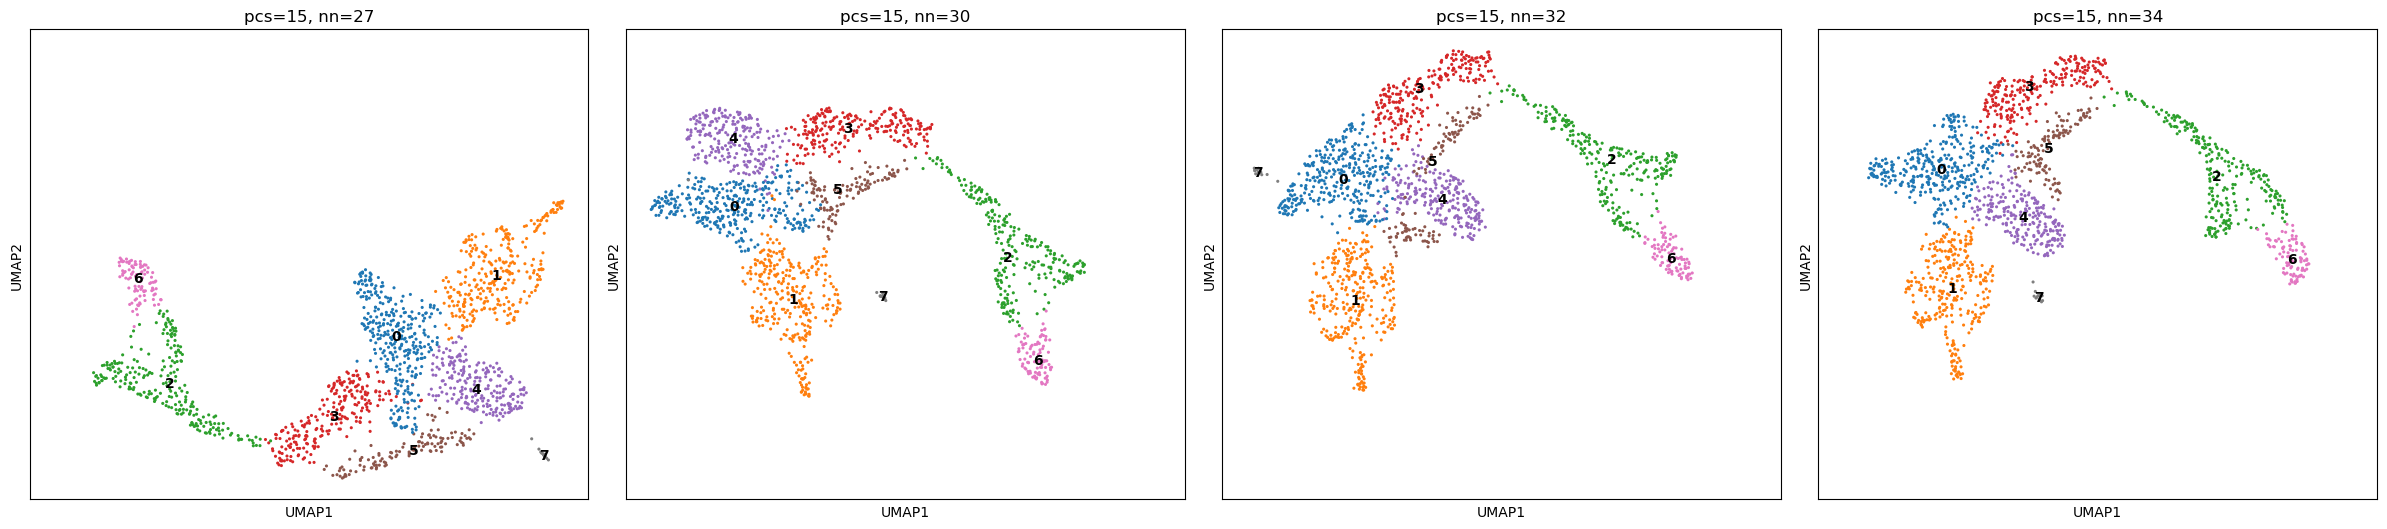


▶ Batch 11/57 | Combos 41–44


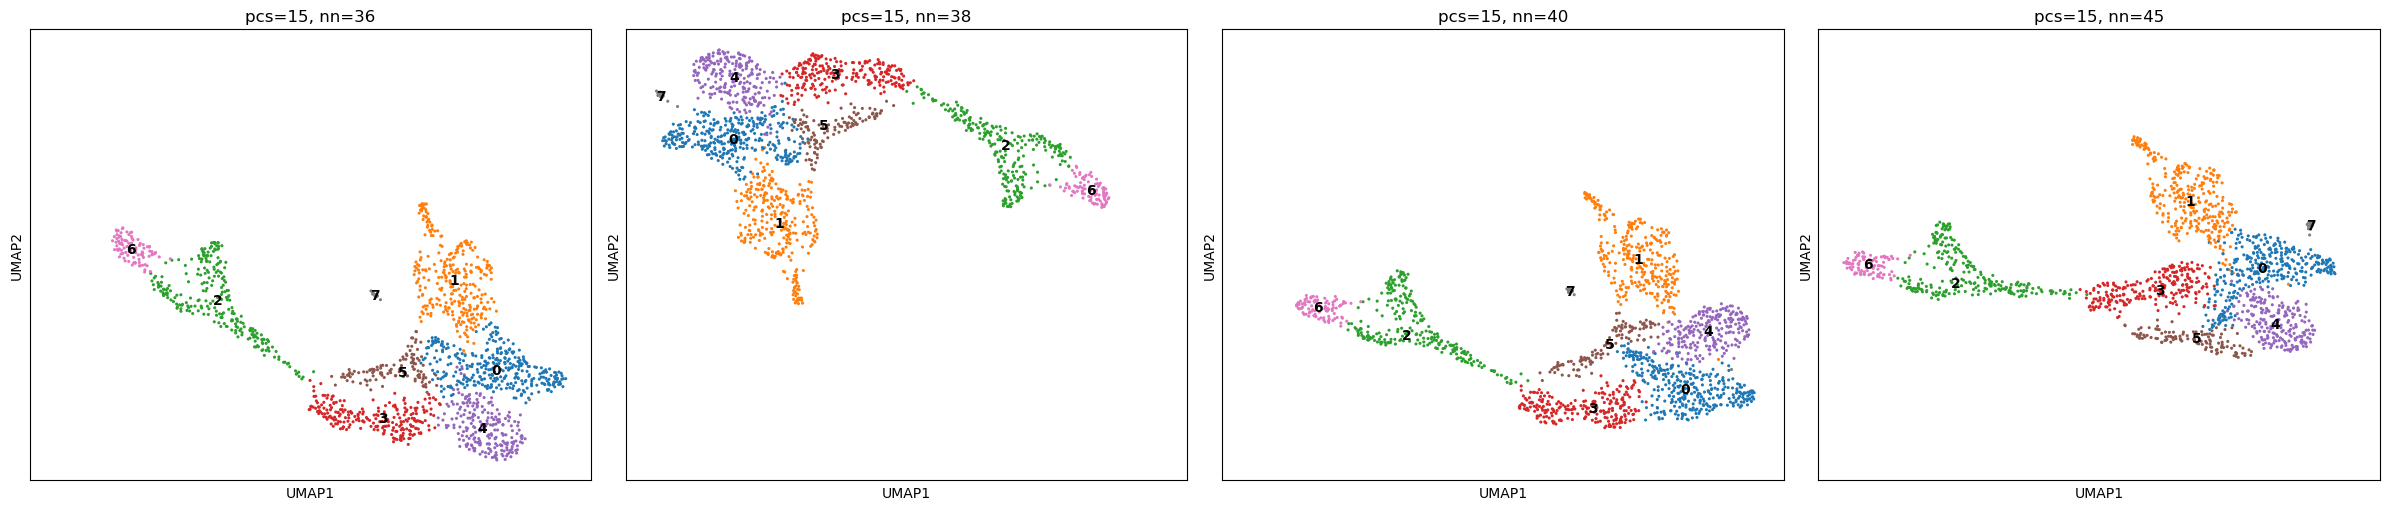


▶ Batch 12/57 | Combos 45–48


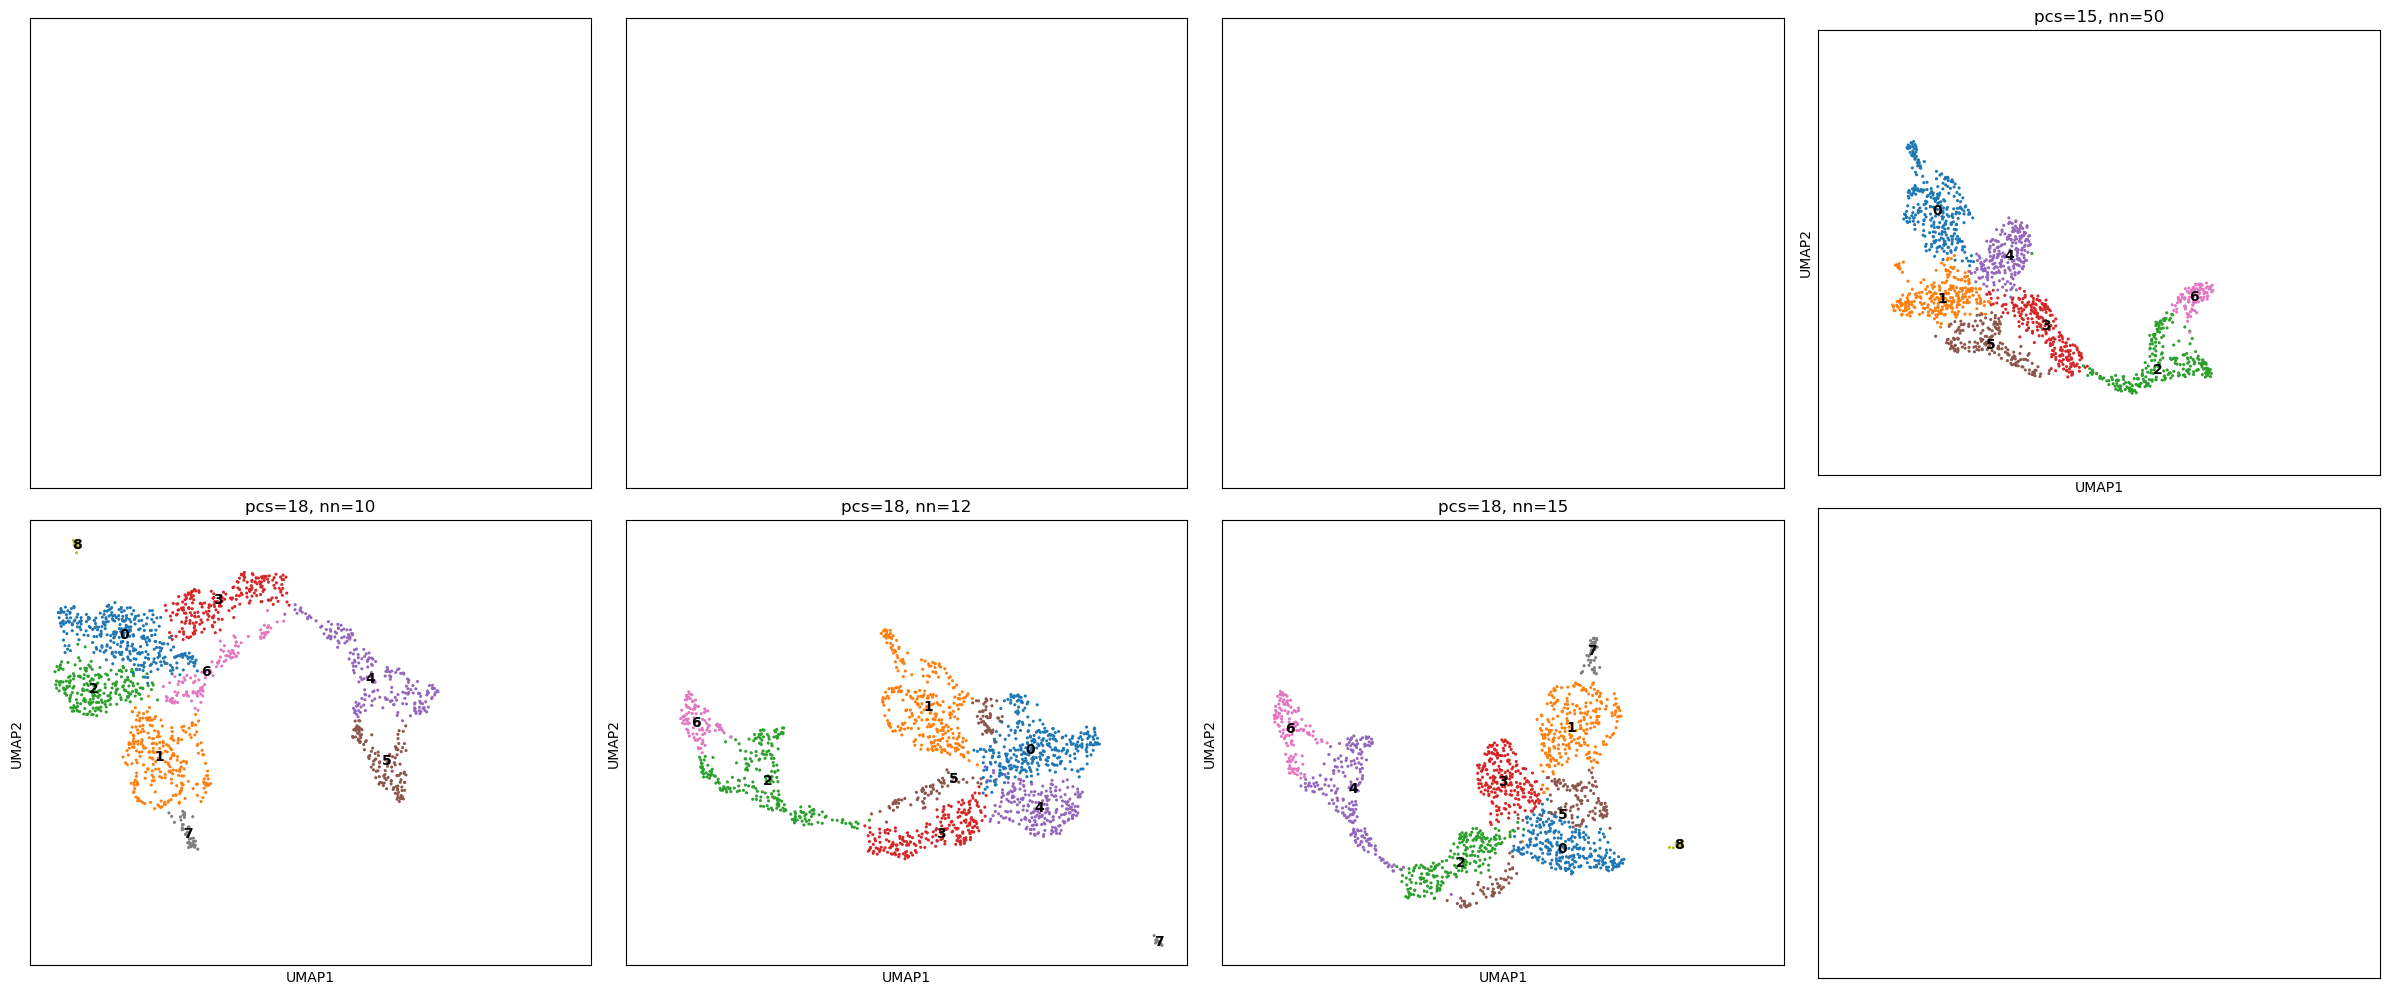


▶ Batch 13/57 | Combos 49–52


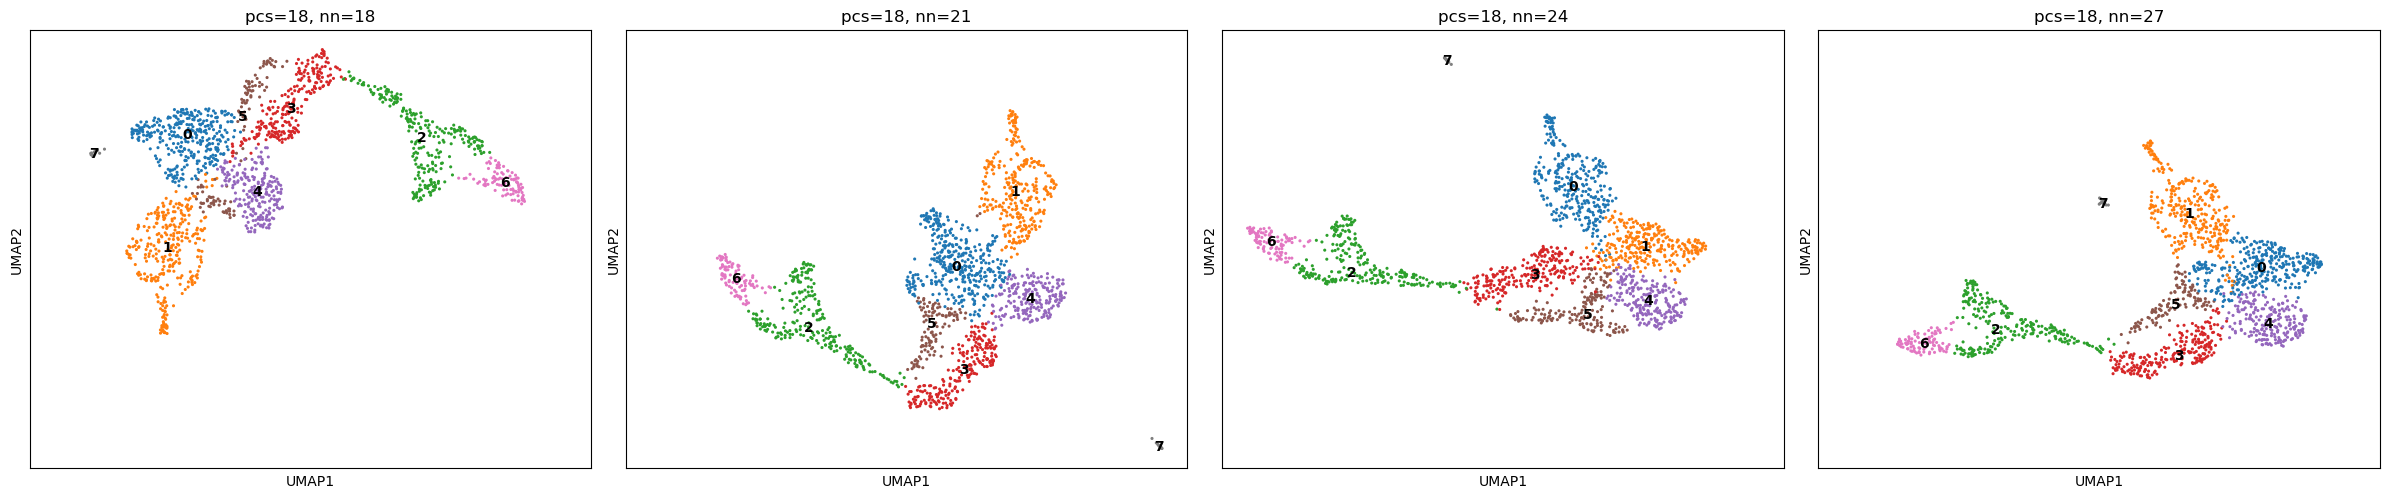


▶ Batch 14/57 | Combos 53–56


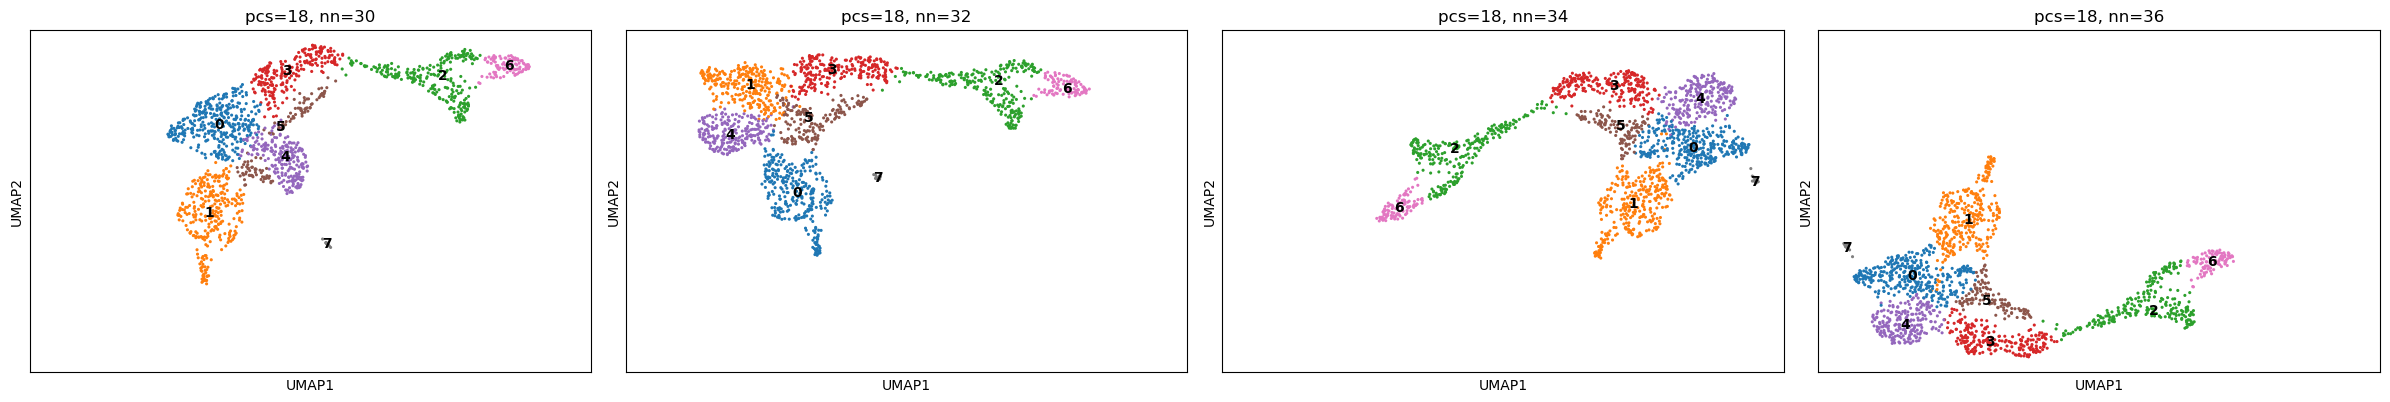


▶ Batch 15/57 | Combos 57–60


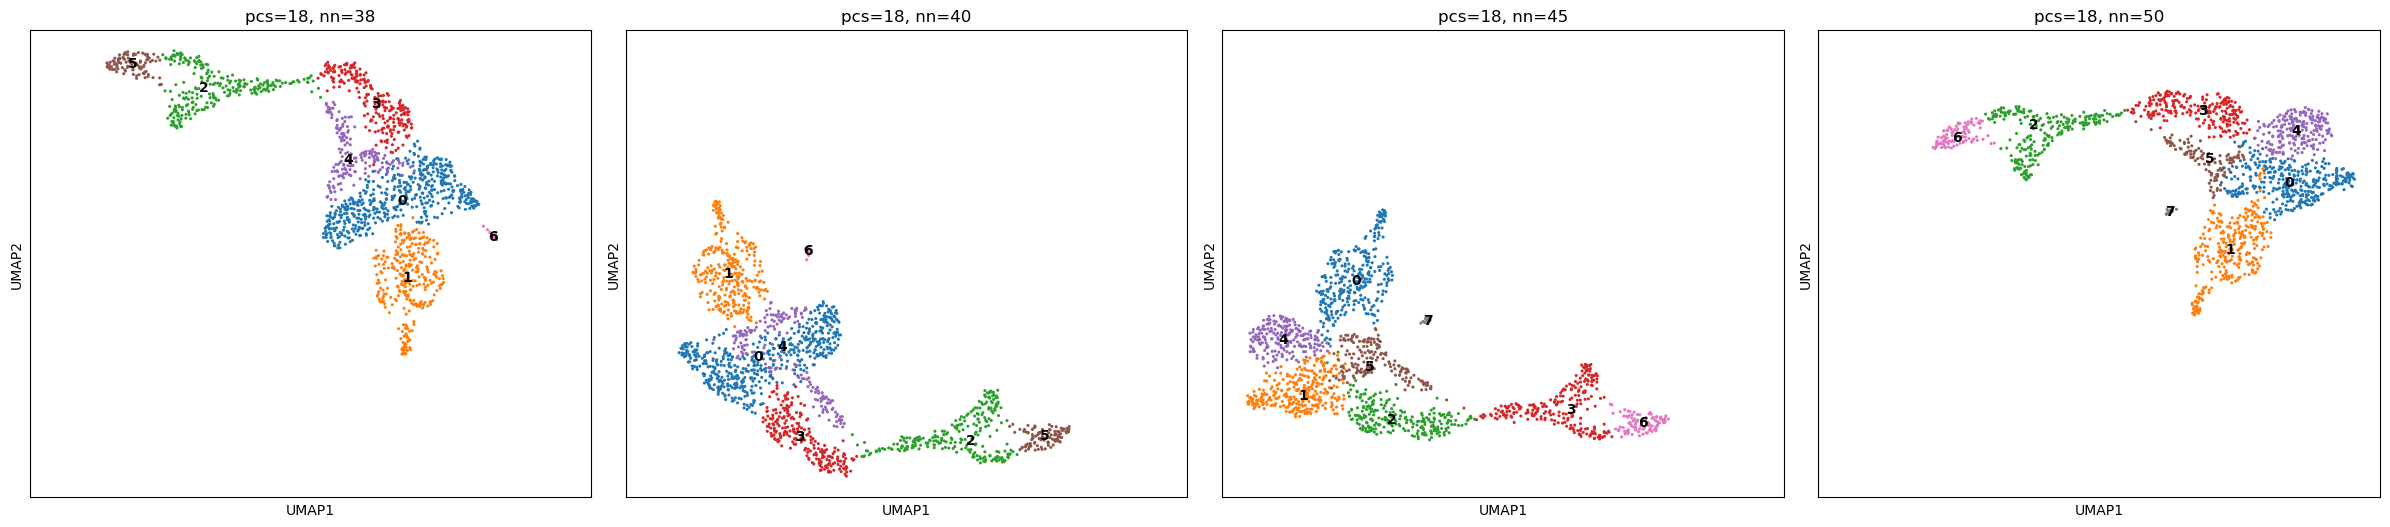


▶ Batch 16/57 | Combos 61–64


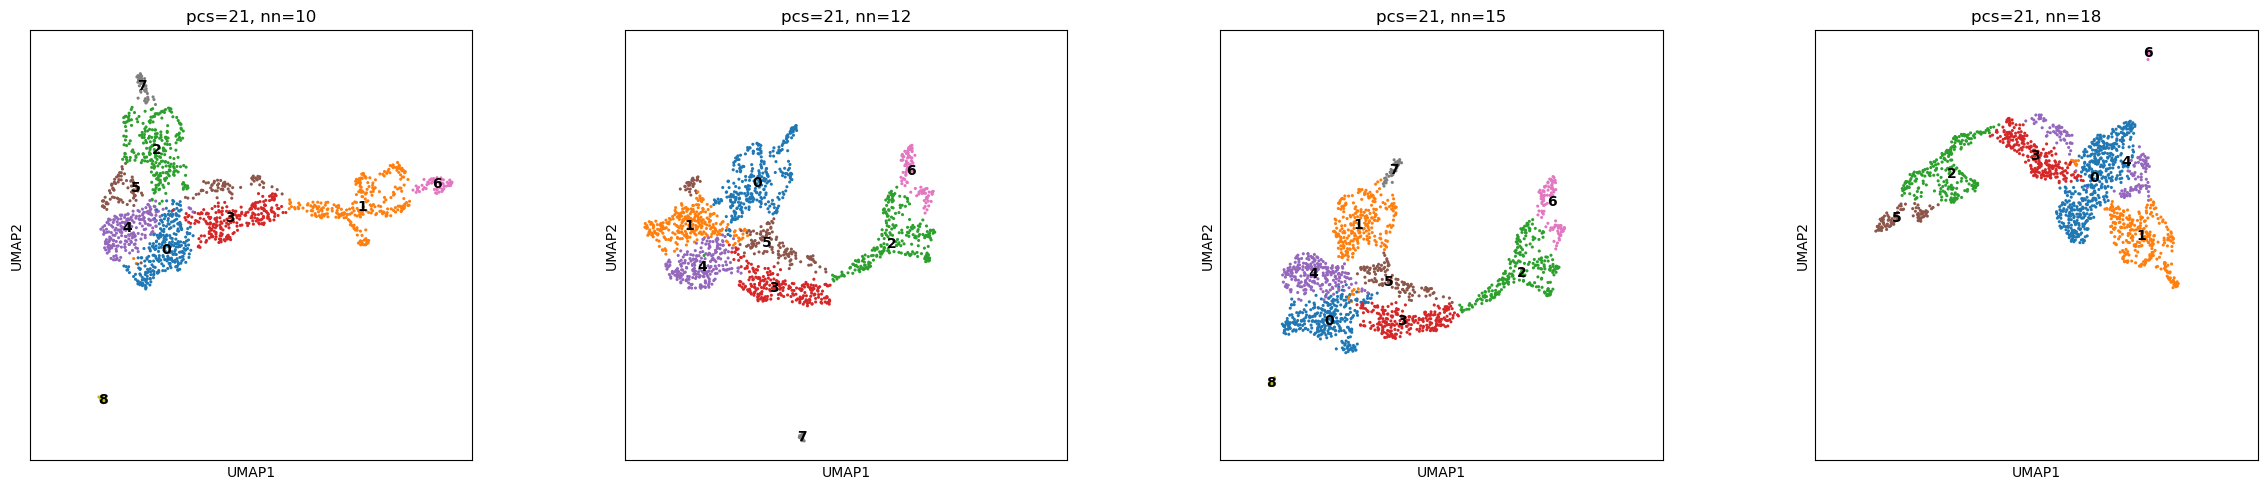


▶ Batch 17/57 | Combos 65–68


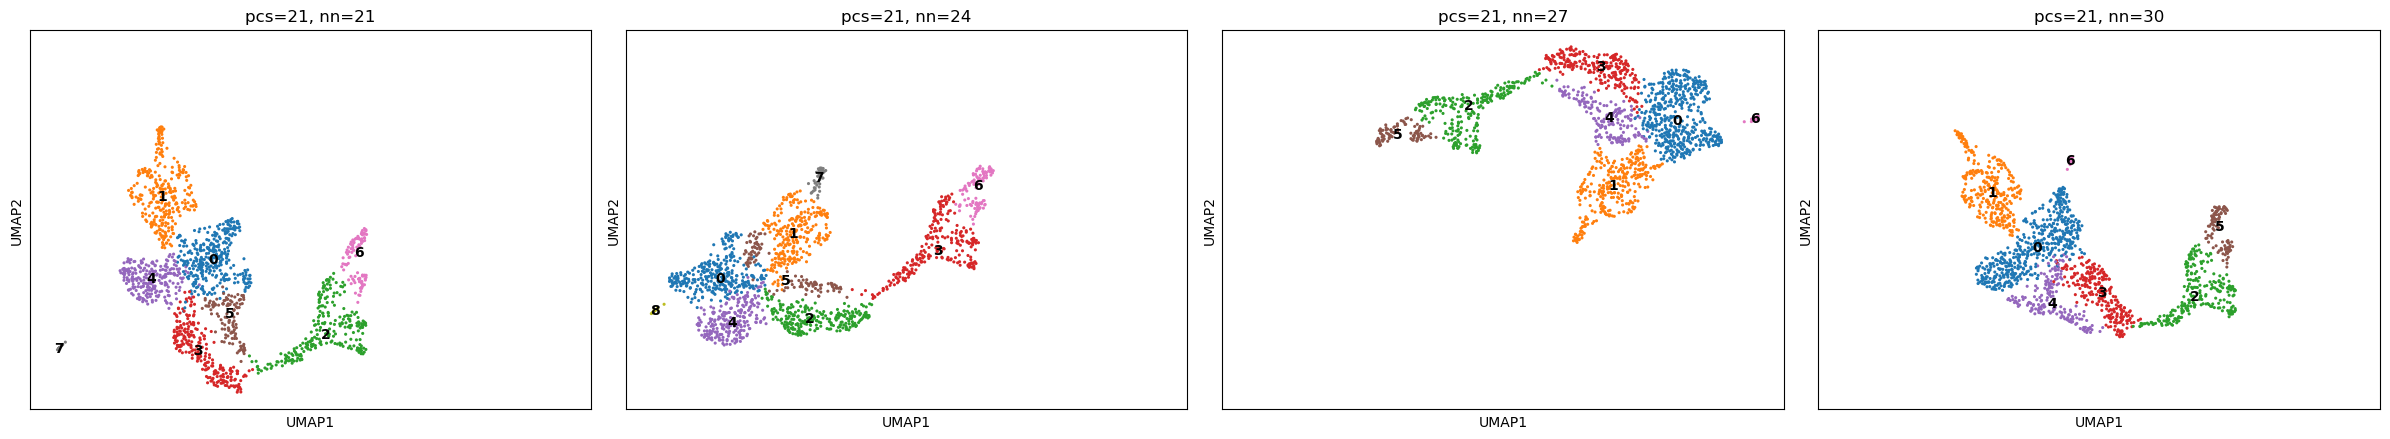


▶ Batch 18/57 | Combos 69–72


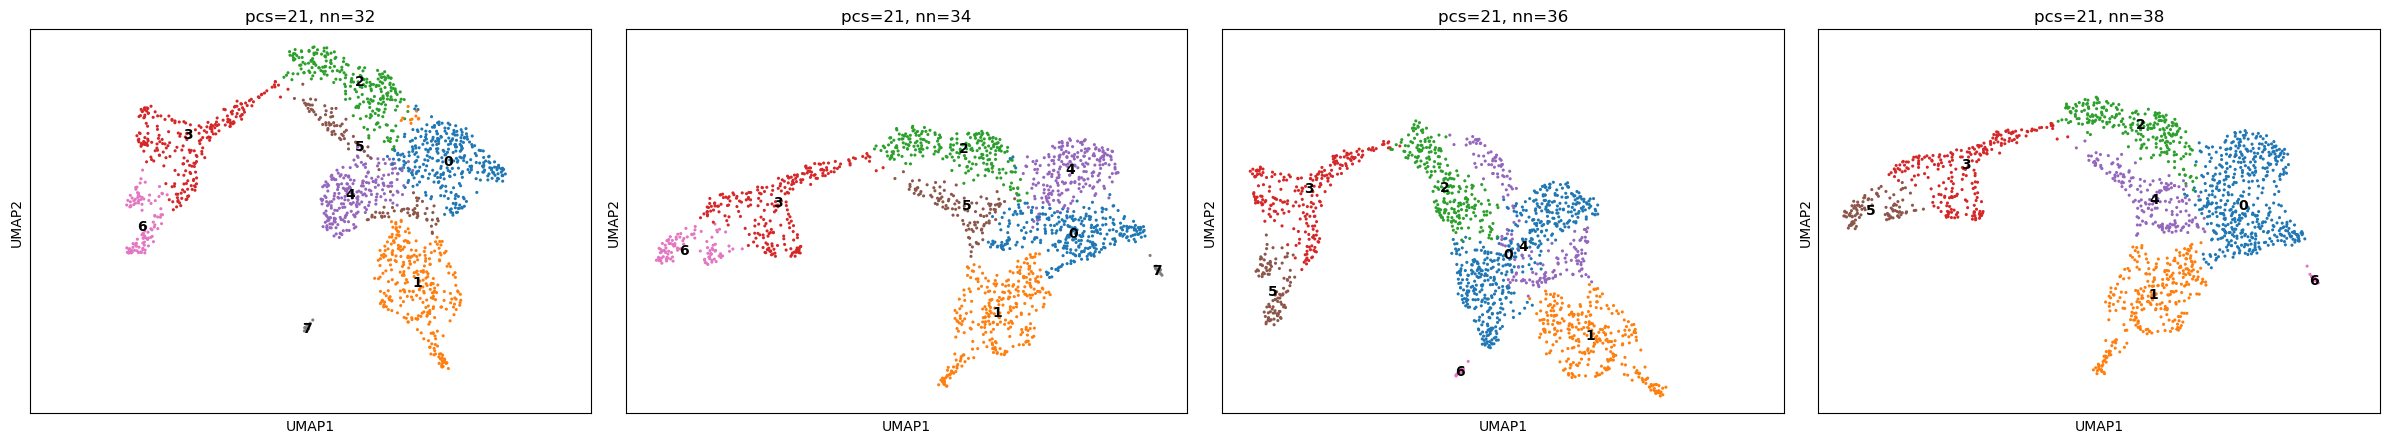


▶ Batch 19/57 | Combos 73–76


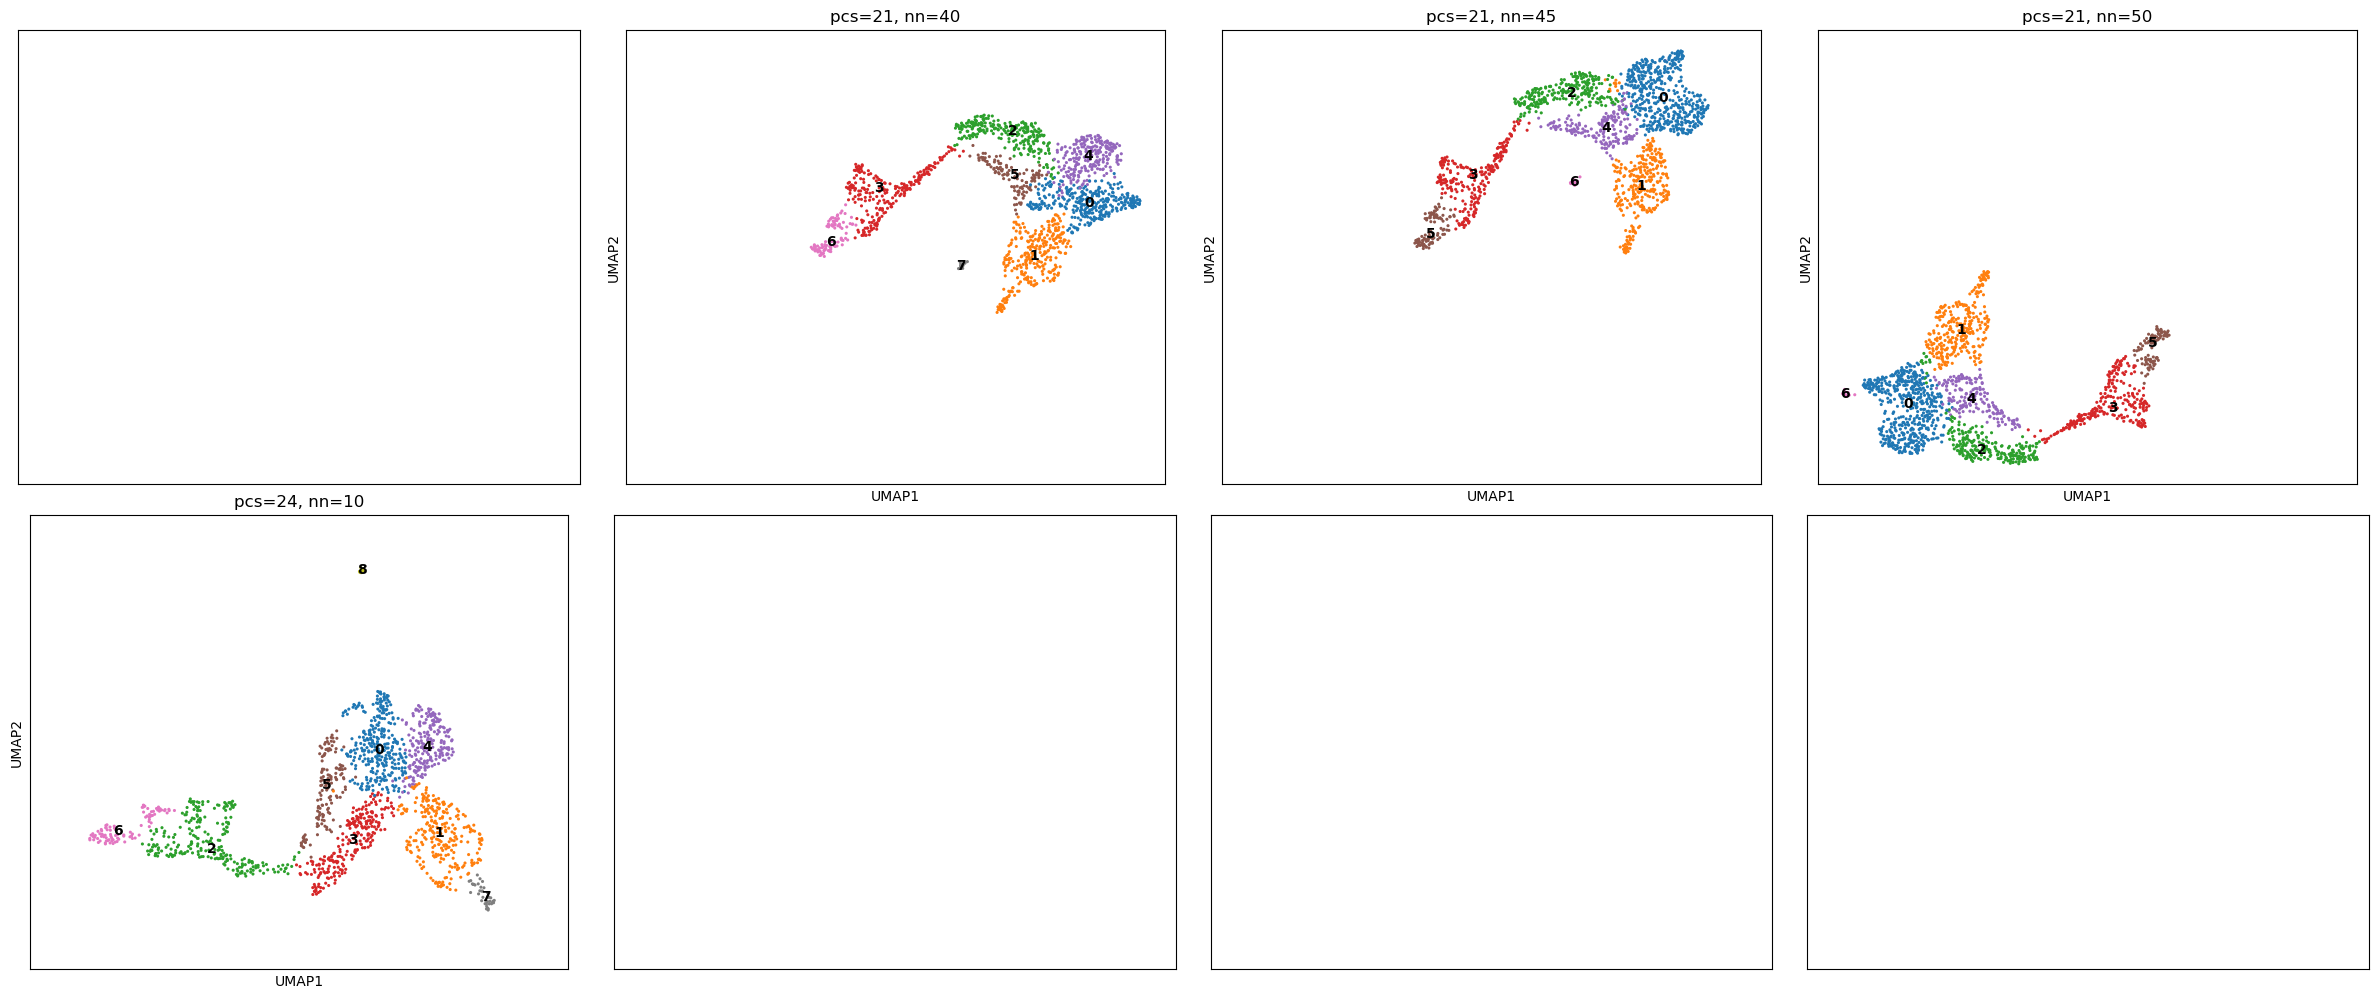


▶ Batch 20/57 | Combos 77–80


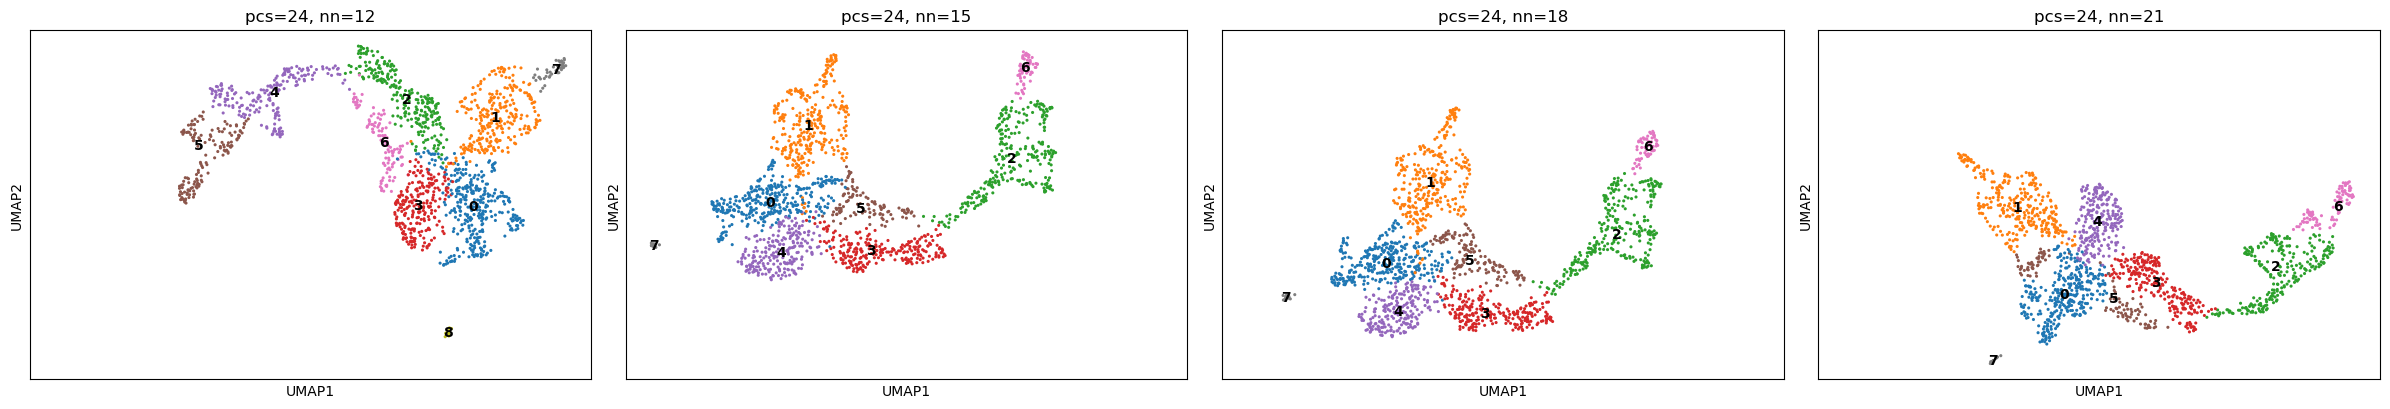


▶ Batch 21/57 | Combos 81–84


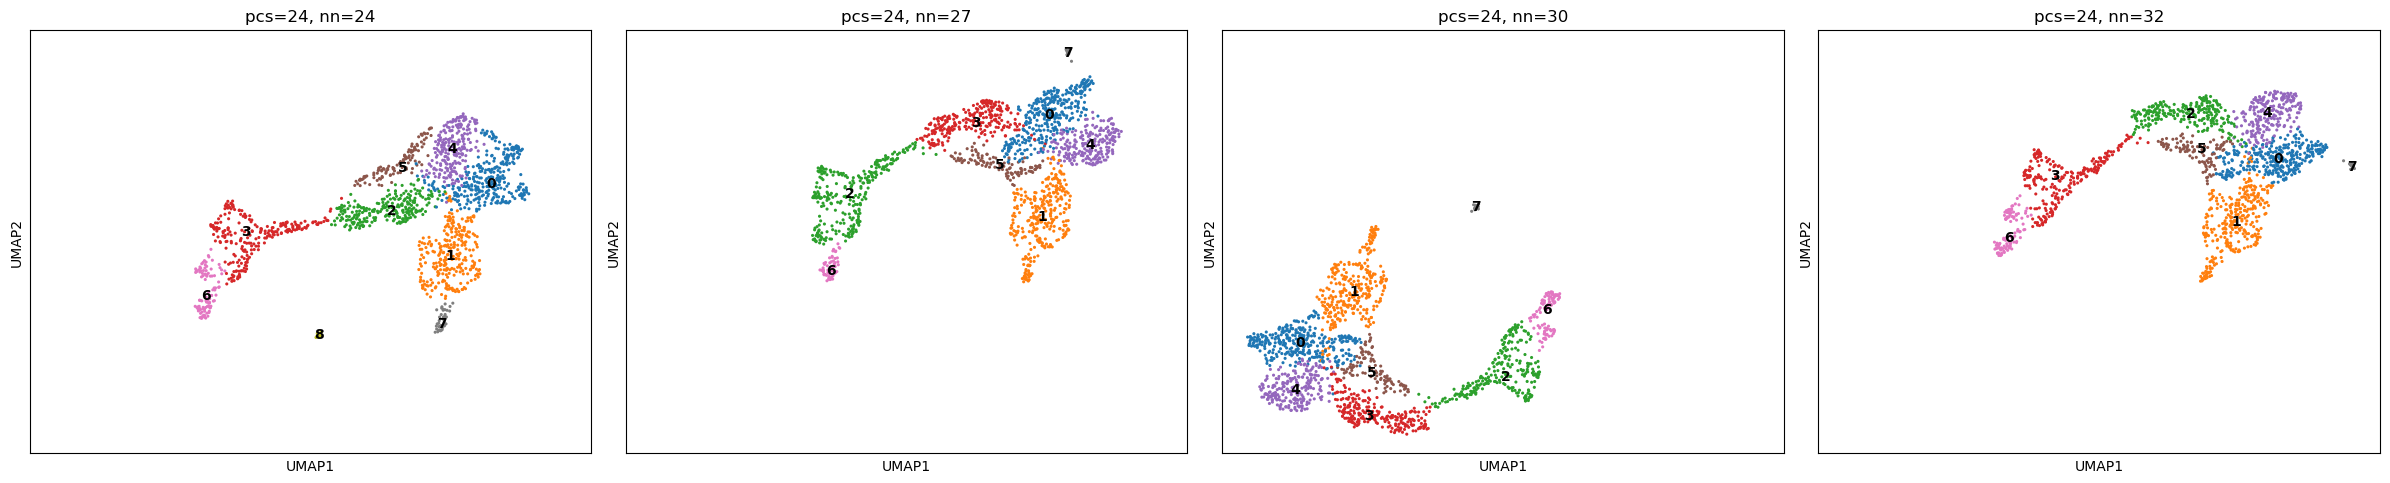


▶ Batch 22/57 | Combos 85–88


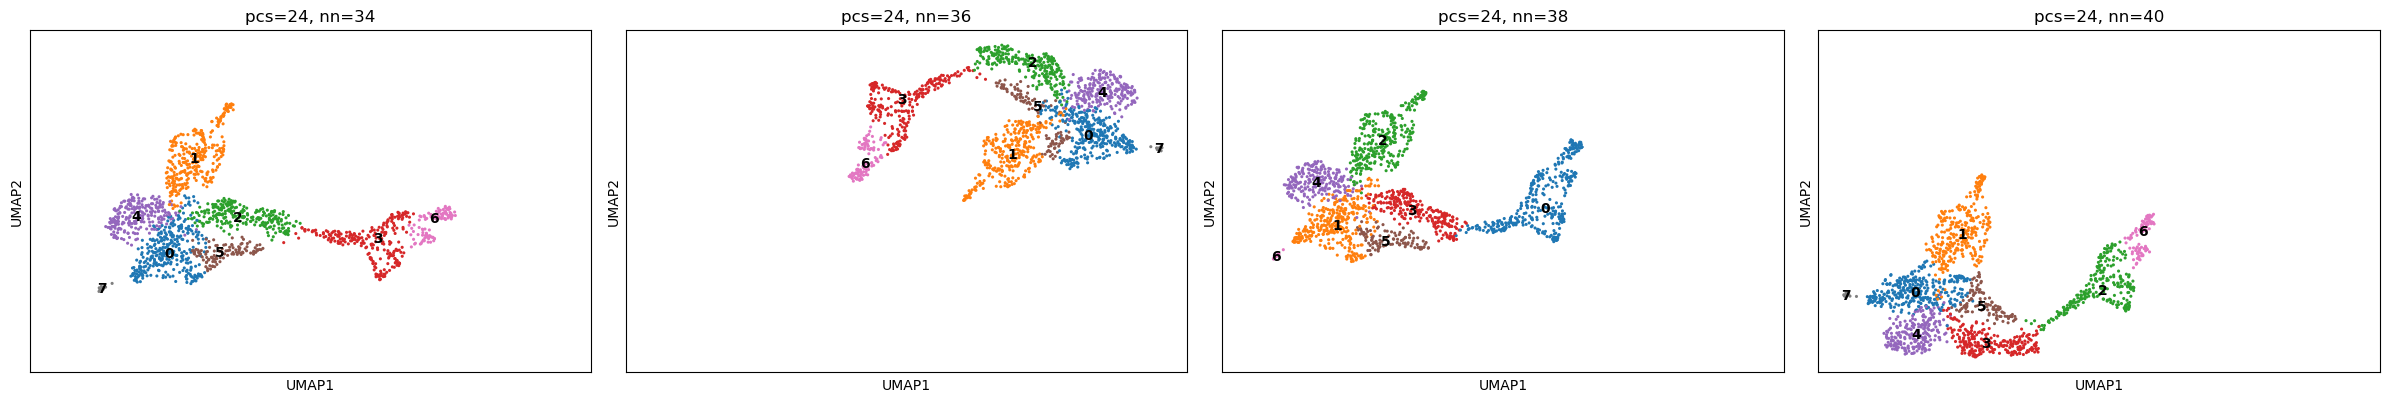


▶ Batch 23/57 | Combos 89–92


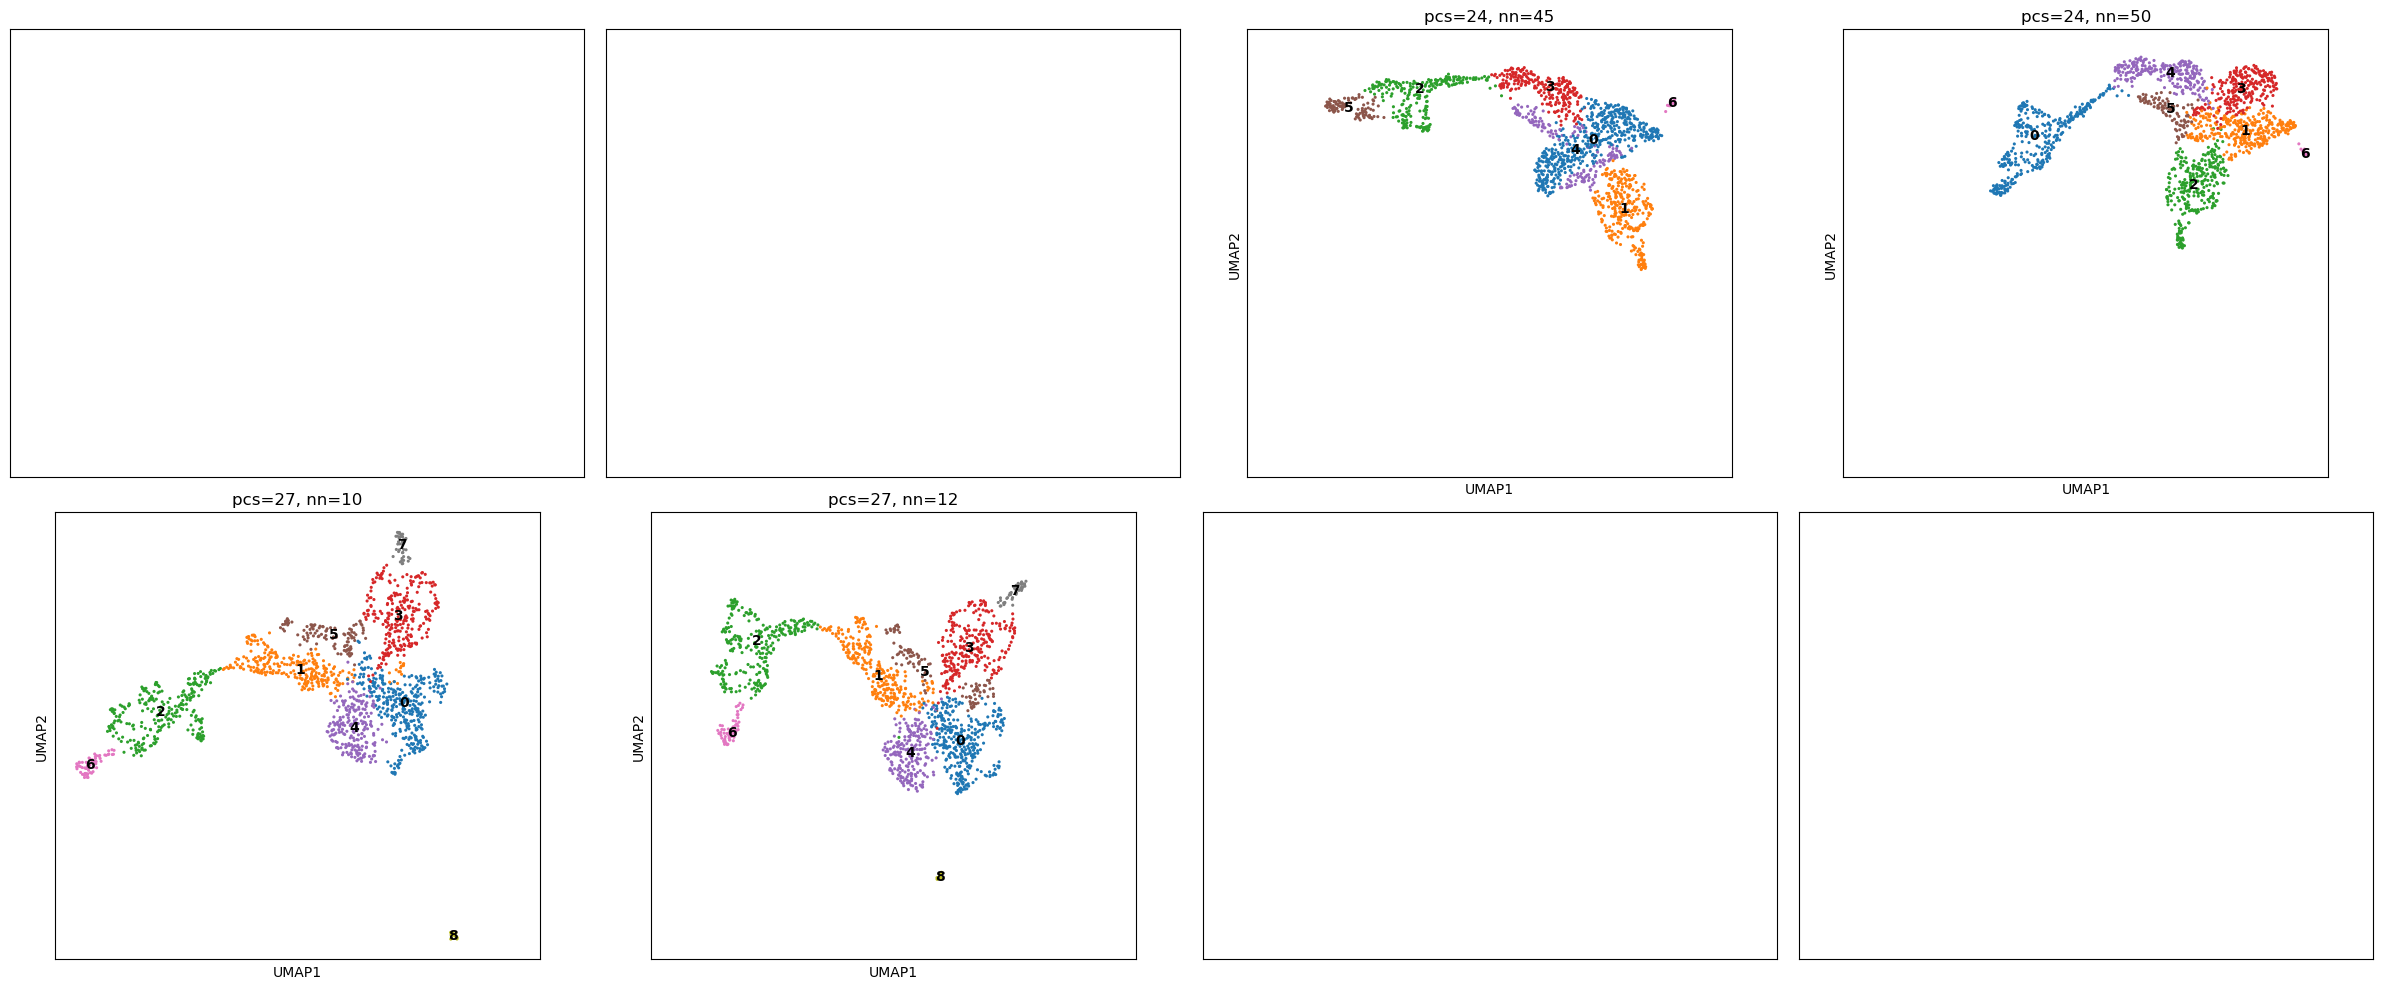


▶ Batch 24/57 | Combos 93–96


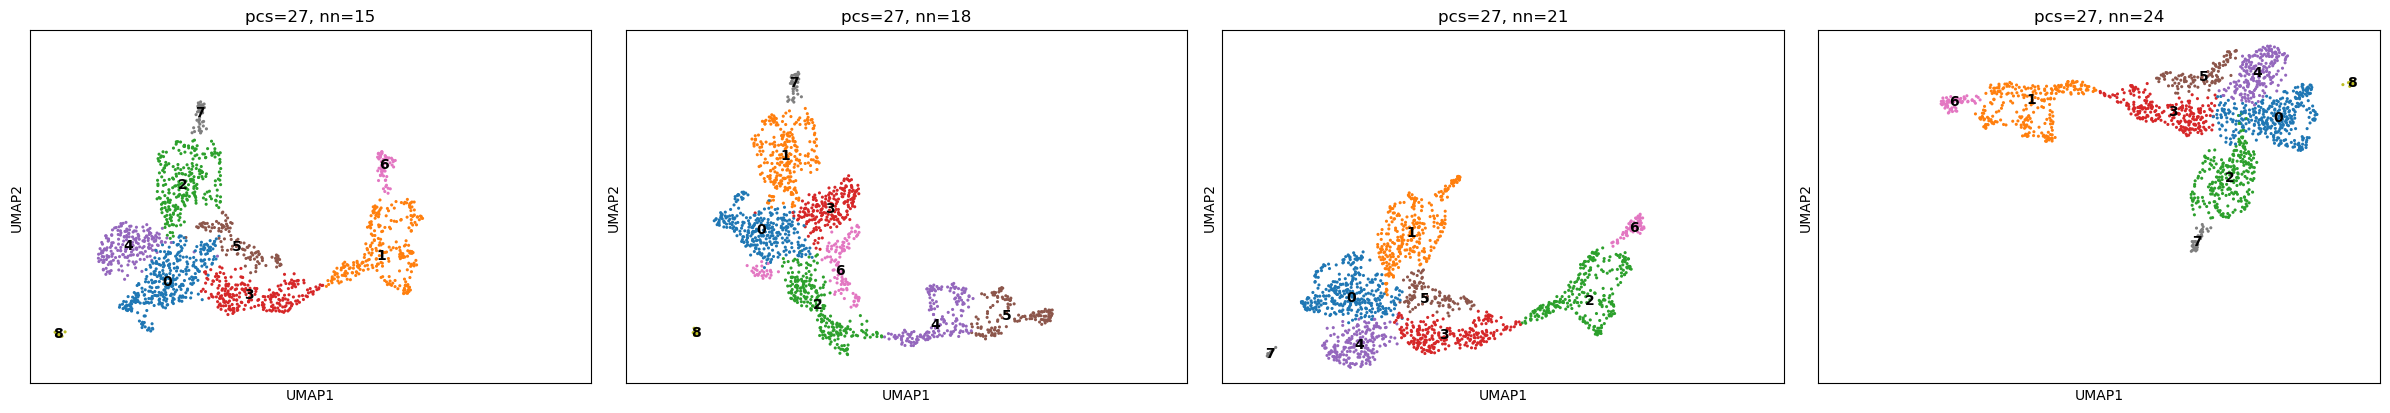


▶ Batch 25/57 | Combos 97–100


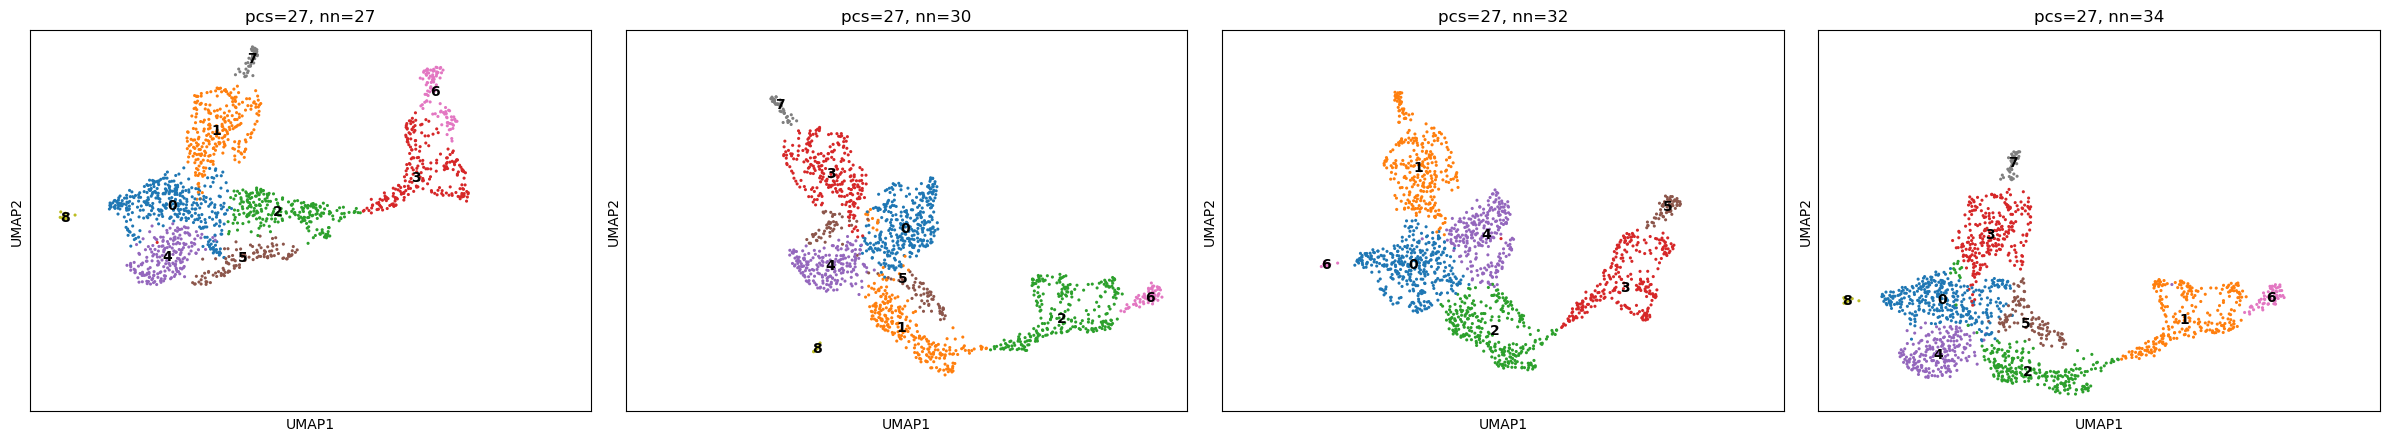


▶ Batch 26/57 | Combos 101–104


KeyboardInterrupt: 

In [8]:
# --- USER PARAMETERS ---
n_pcs_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_neighbors_list = [10, 12, 15, 18, 21, 24, 27, 30, 32, 34, 36, 38, 40, 45, 50]
n_jobs = 4                # Adjust based on memory (10 x ~4GB = ~40GB usage)
batch_size = n_jobs        # Jobs per batch = number of parallel workers
seed=13

resolution = 0.3
point_size = 20
max_pcs = max(n_pcs_list)

# --- INPUT DATA ---
adata_subset_test = adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)

adata_temp = adata_subset_test.copy()


# --- GRID ---
param_grid = [(pcs, nn) for pcs in n_pcs_list for nn in n_neighbors_list]
n_total = len(param_grid)
n_batches = int(np.ceil(n_total / batch_size))

# --- UMAP Function ---
def compute_umap_npc_nn(n_pcs, n_neighbors):
    adata_temp = adata_subset_test.copy()
    sc.pp.neighbors(adata_temp, n_neighbors=n_neighbors, n_pcs=n_pcs,random_state=seed)
    sc.tl.umap(adata_temp,random_state=seed)
    sc.tl.leiden(adata_temp, resolution=resolution,random_state=seed)
    return adata_temp, n_pcs, n_neighbors

# --- RUN BATCHES ---
for batch_i in range(n_batches):
    start = batch_i * batch_size
    end = min((batch_i + 1) * batch_size, n_total)
    batch = param_grid[start:end]

    print(f"\n▶ Batch {batch_i+1}/{n_batches} | Combos {start+1}–{end}")
    #print(adata_temp.obs["leiden"].value_counts(dropna=False))

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_umap_npc_nn)(pcs, nn) for pcs, nn in batch
    )

    # Grid dimensions
    unique_pcs = sorted(set(pcs for pcs, _ in batch))
    unique_nn = sorted(set(nn for _, nn in batch))
    n_rows = len(unique_pcs)
    n_cols = len(unique_nn)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), sharex=True, sharey=True)

    # If only one row or col, axes is not 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for i, (adata_temp, n_pcs, n_neighbors) in enumerate(results):
        row = unique_pcs.index(n_pcs)
        col = unique_nn.index(n_neighbors)
        ax = axes[row, col]

        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"pcs={n_pcs}, nn={n_neighbors}",
            ax=ax,
            show=False,
            legend_loc="on data",
            size=point_size,
            cmap="viridis"
        )
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

In [ ]:
#testing out different spreads
min_dist_list = [0.1,0.3,0.5,0.7,0.8,0.9]
spread_list = [0.8,1.0, 1.3, 1.6, 1.9, 2.2]
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50)
n_rows = len(min_dist_list)
n_cols = len(spread_list)

fig_width = n_cols * 6
fig_height = n_rows * 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)

point_size = max(10, 60 - 5 * max(n_rows, n_cols))

for row, min_dist in enumerate(min_dist_list):
    for col, spread in enumerate(spread_list):
        ax = axes[row, col]
        adata_temp = adata_subset_test.copy()
        

        sc.tl.pca(adata_temp, n_comps=50)        
        sc.pp.neighbors(adata_temp, n_neighbors=32, n_pcs=40)
        sc.tl.umap(adata_temp, min_dist=min_dist, spread=spread)
        sc.tl.leiden(adata_temp)
        
        sc.pl.umap(
            adata_temp,
            color="leiden",
            title=f"min_dist={min_dist}, spread={spread}",
            cmap="viridis",
            ax=ax,
            show=False,
            size=point_size,
            legend_loc="on top"
        )

for ax in axes.flat:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


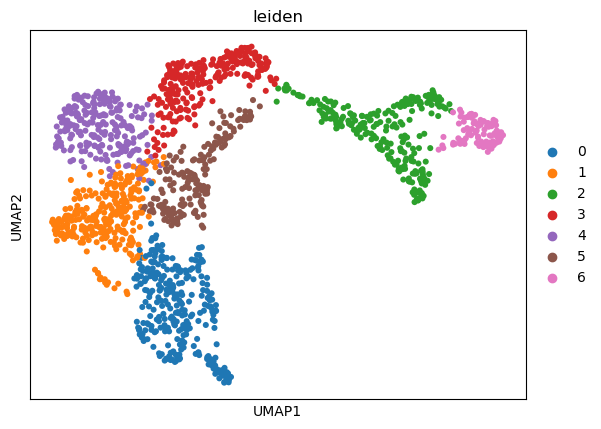

In [9]:
#final subset UMAP
seed=13
n_pcs=12
n_neighbors=34
min_dist=.5
spread=1
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)
sc.pp.neighbors(adata_subset_test, n_pcs=n_pcs, n_neighbors=n_neighbors,random_state=seed)  
sc.tl.umap(adata_subset_test,random_state=seed,min_dist=min_dist,spread=spread)
sc.tl.leiden(adata_subset_test, resolution=0.3,random_state=seed)
sc.pl.umap(adata_subset_test, color="leiden", cmap="viridis",#legend_loc="on data",
         #save=f"_subset_combined_umap.pdf 
          )

In [10]:
adata_subset_test.write(f"/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m3454_adata_subset_again_again_({n_pcs},{n_neighbors})_({min_dist},{spread})_8_3_25.h5ad")

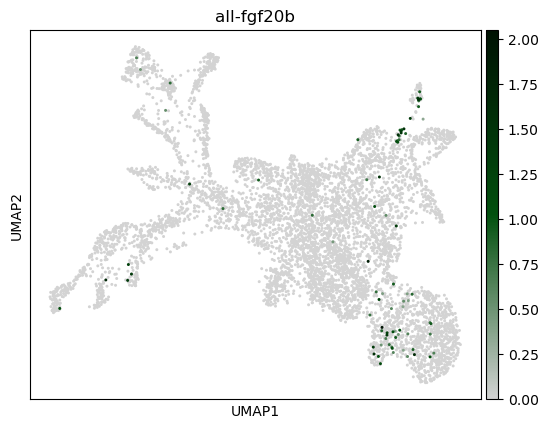

In [22]:
gene="fgf20b"
sc.pl.umap(
    adata_subset_test,
    color=gene,
    title=f"all-{gene}",
    show=True,
    cmap=gray_green,
       #save=f"_subset_gene_umap_{sample}-{gene}.pdf 
    )

In [ ]:
#testing gene on different samples
gene="calb2a"
for sample in adata_subset_test.obs["sample"].unique():
    sc.pl.umap(
        adata_subset_test[adata_subset_test.obs["sample"] == sample],
        color=gene,
        title=f"{sample}-{gene}",
        show=True,
        cmap=gray_green,
       #save=f"_subset_gene_umap_{sample}-{gene}.pdf 
    )

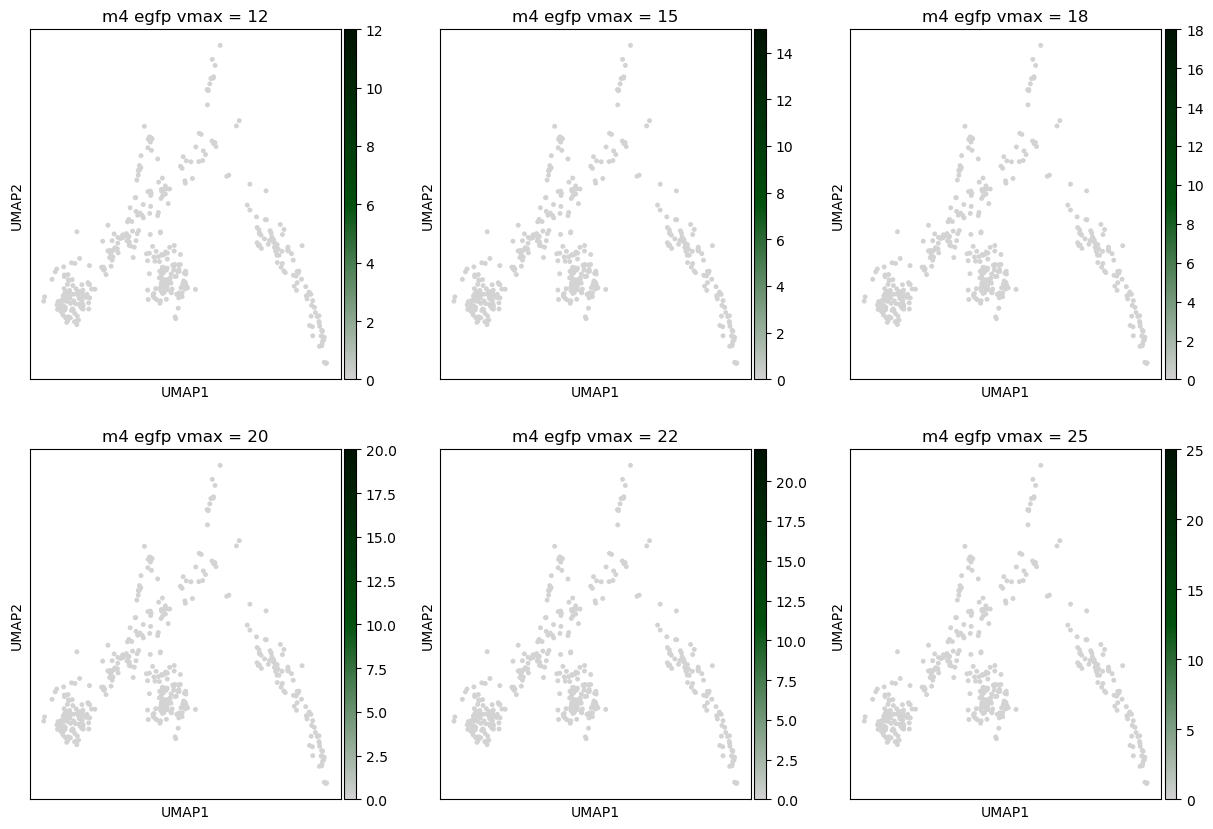

In [35]:
#testing different vmax on same sample
sample='m4'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()

vmax_values = [12,15,18,20,22,25]
#vmax_values = [2,5,8,10,12,6]

ncols = 3
nrows = (len(vmax_values) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

axes = axes.flatten()

for i, vmax in enumerate(vmax_values):
    ax = axes[i]
    sc.pl.umap(
        adata_sample,
        color="egfp",
        vmin=0,
        vmax=vmax,
        size=50,
        title=f"{sample} egfp vmax = {vmax}",
        cmap=gray_green,
        show=False,
        ax=ax  
    )

In [ ]:
sample='m4'
gene='egfp'
adata_sample = adata_subset_test[adata_subset_test.obs["sample"] == f"{sample}"].copy()
sc.pl.umap(
    adata_sample,
    color=gene,
    vmin=0,
    vmax=18,
    size=50,
    title=f'{sample}_{gene}',
    cmap=gray_softorange_orangered,
    #save=f"_subset_umap_{sample}_{gene}.pdf"
)